# 📊 Applying Machine Learning to a Multi-Factor Equity Strategy

**Author:** Dr. Jonas Zink, CFA
**Date:** September 2025
**Google Colab:** [Open in Colab](https://colab.research.google.com/)

---

**Goal.** This notebook builds and tests an equity strategy that blends two classical cross-sectional factors (e.g., Momentum, Low Volatility, Profitability/ROE). A supervised ML model learns **time-varying blend weights** from market/state features and we backtest the resulting portfolio against simple benchmarks.

---

## What you will learn / key questions

- **Does a learned blend** of two factors outperform:
  - a static **50/50** blend and
  - the **index**?
- **Which features** (e.g., factor spreads, factor correlations, RF, VIX) explain the **optimal factor weight**?
- How stable are the learned weights over time, and what is the resulting **risk/return profile**?

---

## Method at a glance

- **GetData**: load prices, index weights, ROE, RF, VIX; resample and align; compute simple returns.
- **GetStockScores**: compute rolling **12-month momentum**, **annualized volatility**, **mean ROE**; assign **quintile ranks** per date & ticker; produce descriptive stats/plots.
- **TrainMLModel**: for each month, **grid search** the blend `w * factor1 + (1-w) * factor2` that maximizes **next-month compounded return** → this `w*` is the regression **target**; features come from recent factor/index behavior and macro proxies.
- **ApplyMLModel**: predict monthly **blend weights**; derive portfolio **stock weights** by rank-weighting and index scaling.
- **CalculateBacktest**: apply weights out-of-sample at **month-end rebalancing**, compute daily portfolio returns, and summarize performance.

---

## Data & Factors

- **Prices** (panel), **index constituent weights**, **ROE**, **RF**, **VIX**.
- **Frequency**: daily; returns derived as simple pct-change.
- **Factors** (cross-sectional, per date):
  - **Momentum (MOM)**: 12-month price change.
  - **Volatility (VOL)**: rolling std of daily returns (annualized).
  - **Profitability (ROE)**: rolling mean of ROE.
- **Ranks**: quintiles via `qcut`; **higher is better** for MOM & ROE; **lower vol = better rank** (inverted mapping).

---

## ML framing

- **Target**: for each month, choose `w* ∈ {0.0,…,1.0}` that maximizes the **next-month** return of `w * f1 + (1-w) * f2`.
- **Features** (examples):
  - **Factor spreads**: prior window returns of MOM/VOL/ROE quintile portfolios.
  - **Dispersion**: cross-sectional std of raw factor values (mom/vol/roe).
  - **Correlations**: MOM–VOL and MOM–ROE cross-sectional correlations.
  - **Macro proxies**: **RF**, **VIX** (scaled from % to decimal).
  - **Market state**: index **past window return** and **annualized volatility**.
- **Models**: Random Forest, LightGBM, XGBoost, CatBoost (configurable).
- **Diagnostics**: in-sample **R²/MSE/MAE**, **feature importances**, **F-scores** and **p-values**.

---

## Portfolio construction & backtest

- **Rebalance**: month-end.
- **Stock weighting**: index weights × factor rank score (normalized to 100%).
- **Strategies compared**:
  - **ML**: time-varying learned weights.
  - **50/50**: static equal blend.
  - **AVG_ML**: constant average of learned weights.
  - **INDEX**: benchmark index weights.
- **Metrics** (annualized): mean return, volatility, **Sharpe** (mean/std; no RF subtraction), **max drawdown**.
- **Plots**: cumulative factor/index paths, **excess** vs. index, overlays with **VIX** and **RF**.

---

## Assumptions & caveats

- **Targets use future returns** only for **training** (grid search on `t` uses returns of `t+1`), predictions are applied **out-of-sample** thereafter.
- **Universe alignment**: common tickers/dates across ranks, returns, and index weights; joint NA masking.
- **Weight sanity**: predicted `w` is clipped to `[0, 1]`.
- **Sharpe** is computed as mean/vol (not excess over RF).
- **RF/VIX scaling**: expected as percentages in the source; converted to decimals in features.

---

## How to read this notebook

1. **Setup & Parameters** – define data paths, frequency, training/test windows, model & feature set.
2. **Data Loading** – inspect coverage and basic availability stats.
3. **Factor Construction** – verify factor ranks and descriptive plots.
4. **Model Training** – review target definition, metrics, and feature importance.
5. **Application & Weights** – examine time series of learned factor weights.
6. **Backtesting** – compare strategies, inspect cumulative returns and risk metrics.
7. **Scenario Grid** – run and summarize alternative model/factor configurations.


# 1. 🔧 Setup & Parameters

In this section we define the global parameters that govern the entire experiment.
They determine how data is loaded, which factors are included, and how the machine learning (ML) model and backtest are executed.

**Main categories of parameters:**

- **Data Handling**
  - `price_frequency_str` / `price_frequency_num`: sampling frequency (`'D'` = daily, 252 periods/year)
  - `update_factor_scores`: whether to recalculate factor ranks or reuse previously saved values

- **Training Window**
  - `training_start_period` / `training_end_period`: defines the in-sample period used for fitting the ML model

- **Backtest Window**
  - `test_start_period` / `test_end_period`: defines the out-of-sample period used for evaluation

- **Model Configuration**
  - `ml_training_factors`: feature set used as model input (e.g., factor correlations, past returns, macro proxies)
  - `relevant_factors`: which factors are blended (e.g., MOM, VOL, ROE)
  - `ml_model`: choice of regression model (Random Forest, LightGBM, XGBoost, CatBoost)

Together, these parameters provide a reproducible environment where different scenarios can be tested simply by overriding selected values.


In [1]:
"""
Applying ML models to dynamically weight equity factors (momentum, volatility, profitability).

Pipeline
--------
1) Load & align data (prices, index weights, ROE, RF, VIX).
2) Compute rolling factor scores and quintile ranks.
3) Train an ML regressor to predict monthly two-factor blend weights.
4) Apply predicted weights to build portfolios.
5) Backtest and report performance metrics.

Notes
-----
- Designed for daily data with monthly rebalancing by default.
- Paths for cached inputs/outputs are configurable via `params`.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import f_regression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

In [2]:
params_ = {'update_factor_scores': False,
           'price_frequency_str': 'D',
           'price_frequency_num': 252,
           'training_start_period': pd.Timestamp('2007-01-31'),
           'training_end_period': pd.Timestamp('2012-12-31'),
           'test_start_period': pd.Timestamp('2013-01-01'),
           'test_end_period': pd.Timestamp('2025-03-20'),
           'ml_training_factors': ['mom_roe_corr', 'past_mom_return', 'past_roe_return',
                                   'past_index_return', 'past_index_vola', 'rf', 'vix'],
           'relevant_factors': ['mom', 'roe'],
           'ml_model': 'RandomForestRegressor'}

# 2. 💾 Data

The dataset combines market, fundamental, and macro information that serves as input for factor construction and model training.

**Sources**

- **Stock Prices**
  Historical equity prices, resampled to the chosen frequency (`price_frequency_str`).
  Used to calculate momentum and volatility measures.

- **Index Weights**
  Benchmark composition (constituent weights per date).
  Forward-filled and normalized so that weights always sum to 1.

- **Return on Equity (ROE)**
  Company fundamentals reshaped into a panel (date × ticker).
  Missing values are filled forward/backward to ensure stability.

- **Risk-Free Rate (RF) and VIX**
  Macro time series aligned with the equity data.
  Used both as direct features and for contextual interpretation.

**Processing Steps**

1. Align all panels on common dates and tickers.
2. Resample prices to the defined frequency.
3. Compute simple returns from resampled prices.
4. Normalize index weights per date.
5. Forward- and backward-fill ROE values.

The resulting dataset provides a harmonized input for factor score calculation, feature extraction, and backtesting.


In [3]:
class GetData:
    """
    Data loader/aligner for prices, index weights, ROE, RF, and VIX.

    Purpose
    -------
    Centralize I/O and basic preprocessing so downstream components receive
    consistently indexed, frequency-aligned DataFrames.

    Attributes
    ----------

    price_frequency_num : int
        Periods-per-year constant used for annualization (e.g., 252 for daily).
    stock_prices : pandas.DataFrame | None
        Wide price panel [date × ticker]. Set by `get_data()`.
    index_weights : pandas.DataFrame | None
        Benchmark weights [date × ticker], forward-filled and row-normalized. Set by `get_data()`.
    roe : pandas.DataFrame | None
        ROE panel [date × ticker], aligned to price index, ffill/bfill. Set by `get_data()`.
    rf : pandas.DataFrame | None
        Risk-free rate time series with a single column 'RF'. Set by `get_data()`.
    vix : pandas.DataFrame | None
        VIX time series with a single column 'VIX'. Set by `get_data()`.
    returns : pandas.DataFrame | None
        Simple returns derived from `stock_prices`. Set by `get_data()`.
    """

    def __init__(self, params: dict):
        # Periods-per-year constant (252 for daily, 12 for monthly, etc.).
        self.price_frequency_num = params['price_frequency_num']

        # Placeholders populated by `get_data()`.
        self.stock_prices = None         # DataFrame: Historical stock prices
        self.index_weights = None        # DataFrame: Benchmark/index weights per period
        self.roe = None                  # DataFrame: Return on equity values for each stock
        self.rf = None                   # DataFrame: Risk-free rate (per period), column 'RF'
        self.vix = None                  # DataFrame: VIX volatility index (per period), column 'VIX'
        self.returns = None              # DataFrame: Calculated simple returns for all stocks

    def get_data(self):
        """
        Load and harmonize all required datasets; compute returns.

        Behavior
        --------
        - Read Excel sheets (mapping, prices, index weights, ROE, RF/VIX),align indices/columns
          via the ticker mapping, forward-fill where appropriate, and row-normalize
          index weights.

        Side Effects
        ------------
        Sets the following attributes:
            - self.stock_prices
            - self.index_weights
            - self.roe
            - self.rf  (single column 'RF')
            - self.vix (single column 'VIX')
            - self.returns  (pct_change from `stock_prices`)

        Notes
        -----
        - Index weights are reindexed to the price calendar, forward-filled, and normalized
          so each row sums to 1.
        - ROE is aligned to the price index and filled forward/backward for robustness.
        - Returns are simple (not log) returns computed with `pct_change(fill_method=None)`.
        """

        # Fast path: load preprocessed binary bundle if available/desired.
        # === Ingest from Excel sources and perform alignment/cleanup ===

        # 1) Security code → ticker mapping (e.g., MSCI to Bloomberg tickers)
        ticker_mapping = pd.read_excel(r'data.xlsx', sheet_name='isin_msci_ticker_mapping')
        ticker_mapping.drop(columns=['Unnamed: 0'], inplace=True)
        ticker_mapping['MSCI_SECURITY_CODE'] = ticker_mapping['MSCI_SECURITY_CODE'].astype(str)
        ticker_mapping['BBG_TICKER'] = ticker_mapping['BBG_TICKER'].astype(str)
        mapping_dict = dict(zip(
            ticker_mapping['MSCI_SECURITY_CODE'],
            ticker_mapping['BBG_TICKER'])
        )

        # 2) Prices: set date index, resample if needed, then rename/keep mapped tickers
        stock_prices = pd.read_excel(r'data.xlsx', sheet_name='stock_prices')
        stock_prices.index = stock_prices['POS_DATE']
        stock_prices.drop(columns=['POS_DATE'], inplace=True)

        stock_prices = stock_prices.rename(columns=mapping_dict)
        stock_prices = stock_prices.loc[:, stock_prices.columns.isin(mapping_dict.values())]

        # 3) Index weights: align to price calendar, ffill, row-normalize
        index_weights = pd.read_excel(r'data.xlsx', sheet_name='index_weights')
        index_weights.index = index_weights['AS_OF_DATE']
        index_weights.drop(columns=['AS_OF_DATE'], inplace=True)
        index_weights = index_weights.rename(columns=mapping_dict)
        index_weights = index_weights.loc[:, index_weights.columns.isin(mapping_dict.values())]
        bidx = stock_prices.index.unique()
        index_weights = index_weights.reindex(bidx).ffill()
        index_weights = index_weights.div(index_weights.sum(axis=1), axis=0)  # row-normalize

        # 4) ROE: pivot to wide format, align to prices, fill both directions
        roe_raw = pd.read_excel(r'data.xlsx', sheet_name='roe')
        roe = roe_raw.pivot(index='AS_OF_DATE', columns='MSCI_SECURITY_CODE', values='ROE')
        roe.index = pd.to_datetime(roe.index, format='%d.%m.%y')
        roe.sort_index(inplace=True)
        roe.columns = roe.columns.astype(str)
        roe = roe.rename(columns=mapping_dict)
        roe = roe.loc[:, roe.columns.isin(mapping_dict.values())]
        roe = roe.ffill().bfill()
        roe = roe[stock_prices.index.min():stock_prices.index.max()]
        roe.columns.name = None
        bidx = stock_prices.index.unique()
        roe = roe.reindex(bidx).ffill()

        # 5) RF & VIX: keep as two-column frame with index as datetime
        rf_vix = pd.read_excel(r'data.xlsx', sheet_name='rf_vix')
        rf_vix.index = rf_vix['Date']
        rf_vix.drop(columns=['Date'], inplace=True)
        rf_vix.index = pd.to_datetime(rf_vix.index)

        # Bundle for optional caching and uniform downstream assignment
        data_dictionary = {
            'stock_prices': stock_prices,
            'index_weights': index_weights,
            'roe': roe,
            'rf_vix': rf_vix
        }


        # === Assign canonical attributes for downstream components ===
        self.stock_prices = data_dictionary['stock_prices']
        self.index_weights = data_dictionary['index_weights']
        self.roe = data_dictionary['roe']
        self.rf = data_dictionary['rf_vix'][['RF']].copy(deep=True)
        self.vix = data_dictionary['rf_vix'][['VIX']].copy(deep=True)

        # Simple returns (no fill tricks): preserves NaNs where prices are missing
        self.returns = data_dictionary['stock_prices'].pct_change(fill_method=None)

# 3. 🏅 Calculate Stock Ranks

In this step, raw factor signals are transformed into standardized quintile ranks for each stock and date.
This ensures comparability across the cross-section and enables consistent portfolio construction.

**Factors and Metrics**

- **Momentum (MOM)** — N-period price performance (typically ~12 months):

  $$
  \mathrm{MOM}_{i,t} \;=\; \frac{P_{i,t}}{P_{i,t-N}} \;-\; 1
  $$

- **Volatility (VOL)** — rolling standard deviation of daily returns (annualized):

  $$
  \mathrm{VOL}_{i,t} \;=\; \operatorname{Std}\!\big(r_{i,t-N+1:t}\big)\;\times\;\sqrt{252}
  $$

- **Profitability (ROE)** — rolling mean ROE over the same window:

  $$
  \mathrm{ROE}_{i,t} \;=\; \operatorname{Mean}\!\big(\mathrm{ROE}_{i,t-N+1:t}\big)
  $$

**Ranking Procedure**

1. For each month-end, compute raw values for all available stocks.
2. Assign **quintile ranks** (1 = lowest, 5 = highest) using `pd.qcut`.
   - **Momentum & ROE:** descending (higher values → higher rank).
   - **Volatility:** **inverted** (lower volatility → higher rank), implemented via descending rank + labels `[1,2,3,4,5]`.
3. Persist rank panels: `mom_ranks`, `vol_ranks`, `roe_ranks`.

**Purpose**

These ranked factor panels form the foundation for:
- Constructing factor portfolios,
- Deriving **training targets** for the ML model,
- Evaluating the standalone performance of each factor relative to the index.

> **Note:** The window length \(N\) corresponds to your `price_frequency_num` (e.g., \(N=252\) for daily data ≈ 12 months).


In [4]:
class GetStockScores:
    """
    Compute rolling factor metrics and quintile ranks; produce descriptive plots/stats.

    Purpose
    -------
    Provide factor panels (12m momentum, annualized volatility, mean ROE), their
    date-by-date quintile ranks, and a descriptive analysis bundle (tables + figures)
    used by downstream ML and reporting steps.

    Attributes
    ----------
    price_frequency_num : int
        Window length used for rolling ops and annualization (e.g., 252 for daily).
    params : dict
        Full configuration dictionary passed from the pipeline.
    data : GetData
        Handle to preloaded market/factor data (prices, returns, weights, RF, VIX).
    roe, stock_prices, rf, vix, returns : pandas.DataFrame
        Direct references to the underlying inputs from `data`.
    relevant_factors : list[str]
        Factors expected downstream (e.g., ['mom','vol','roe']).

    mom_ranks, vol_ranks, roe_ranks : pandas.DataFrame | None
        Quintile ranks (date × ticker). Convention:
        - MOM, ROE: descending ranks → labels [5,4,3,2,1] (5 = top quintile).
        - VOL:      inverse mapping via labels [1,2,3,4,5] after descending rank
                    (i.e., lower volatility ⇒ higher effective score).
    perf_12m, vol_12m, roe_12m : pandas.DataFrame | None
        Raw factor panels:
        - perf_12m: price / price.shift(N) − 1
        - vol_12m : rolling std(returns) × sqrt(periods/year)
        - roe_12m : rolling mean ROE
    return_stats : dict | None
        Basic window and availability stats for returns panel.
    factor_stats : pandas.DataFrame | None
        Performance stats for factor portfolios and index (via `get_return_stats`).
    factor_returns_cum : pandas.DataFrame | None
        Cumulative factor returns (not stored directly; intermediate).
    factor_returns_cum_full : pandas.DataFrame | None
        Cumulative factor and index returns, plus RF/VIX (aligned).
    numb_companies_fig, cum_returns_fig : matplotlib.figure.Figure | None
        Figures for (i) universe breadth over time and (ii) cumulative perf plot.
    vix_excess_return_figs, rf_excess_returns_figs : dict[str, Figure] | None
        One figure per factor comparing cumulative excess vs. VIX / RF.
    rf_vix_fig : matplotlib.figure.Figure | None
        Dual-axis plot of RF and VIX over the sample.
    """

    def __init__(self, data: GetData, params: dict):
        """
        Initialize with references to input data and configuration.

        Parameters
        ----------
        data : GetData
            Preloaded data container (prices, returns, index weights, RF, VIX, ROE).
        params : dict
            Configuration with keys such as:
              - 'price_frequency_num'
              - 'update_factor_scores'
              - 'relevant_factors'
        """

        # Frequency number (periods per year), e.g. 252 for daily, 12 for monthly, etc.
        self.price_frequency_num = params['price_frequency_num']
        self.params = params

        # Save reference to input data object (for access to assets/factors/prices)
        self.data = data

        # Expose main dataframes as attributes
        self.roe = data.roe
        self.stock_prices = data.stock_prices
        self.rf = data.rf
        self.vix = data.vix
        self.returns = data.returns

        # Whether to update factor scores dynamically (True: rolling, False: fixed)
        self.update_factor_scores = params['update_factor_scores']

        # Define which model factors to use (e.g. ['mom', 'vol', 'roe'])
        self.relevant_factors = params['relevant_factors']

        # Attributes to hold computed scores/ranks (will be set by scoring methods)
        self.mom_ranks = None  # Momentum ranks
        self.vol_ranks = None  # Volatility ranks
        self.roe_ranks = None  # ROE ranks

        self.perf_12m = None  # 12-month price performance (raw values)
        self.vol_12m = None  # 12-month price volatility (stddev)
        self.roe_12m = None  # 12-month average ROE (or TTM value)

        self.return_stats = None
        self.numb_companies_fig = None

        self.factor_stats = None
        self.factor_returns_cum = None
        self.factor_returns_cum_full = None

        self.vix_excess_return_figs = None
        self.rf_excess_returns_figs = None
        self.rf_vix_fig = None
        self.cum_returns_fig = None

    def get_stock_scores(self):
        """
        Generate rolling factor metrics and assign quintile ranks per date.

        Computes
        --------
        - 12-month momentum: price / price.shift(N) − 1.
        - 12-month volatility: rolling std of returns × sqrt(periods/year).
        - 12-month mean ROE: rolling average.
        - Quintile ranks via `pd.qcut` (descending for MOM/ROE; inverted mapping for VOL).

        Sets
        ----
        self.mom_ranks, self.vol_ranks, self.roe_ranks,
        self.perf_12m, self.vol_12m, self.roe_12m
        """

        # Re-calculate factor scores if requested, else load from cache
        # ===== 1. Compute rolling raw factor metrics =====
        # 12-month (or N-period) momentum: (current price / price N periods ago) - 1
        perf_12m = self.stock_prices / self.stock_prices.shift(self.price_frequency_num) - 1
        # 12-month volatility: Rolling std dev of returns, annualized
        vol_12m = self.returns.rolling(self.price_frequency_num).std() * np.sqrt(self.price_frequency_num)
        # 12-month average ROE: Rolling mean
        roe_12m = self.roe.rolling(self.price_frequency_num).mean()

        # ===== 2. Initialize empty rank DataFrames =====
        mom_ranks = pd.DataFrame(index=perf_12m.index, columns=perf_12m.columns)
        vol_ranks = pd.DataFrame(index=vol_12m.index, columns=vol_12m.columns)
        roe_ranks = pd.DataFrame(index=vol_12m.index, columns=vol_12m.columns)

        # ===== 3. For each date, assign quintile ranks for each factor =====
        for date in vol_12m.index:
            row_mom = perf_12m.loc[date]
            row_vol = vol_12m.loc[date]
            row_roe = roe_12m.loc[date]

            try:
                # Higher is better for momentum/ROE: rank descending, vol: rank descending (lower vol = higher quintile)
                ranks_mom = row_mom.rank(method="first", ascending=False)
                quintiles_mom = pd.qcut(ranks_mom, q=5, labels=[5, 4, 3, 2, 1])
                mom_ranks.loc[date] = quintiles_mom

                ranks_vol = row_vol.rank(method="first", ascending=False)
                quintiles_vol = pd.qcut(ranks_vol, q=5, labels=[1, 2, 3, 4, 5])
                vol_ranks.loc[date] = quintiles_vol

                ranks_roe = row_roe.rank(method="first", ascending=False)
                quintiles_roe = pd.qcut(ranks_roe, q=5, labels=[5, 4, 3, 2, 1])
                roe_ranks.loc[date] = quintiles_roe

            except ValueError:
                # If not enough non-NA values to split into quintiles, assign NAs
                mom_ranks.loc[date] = np.nan
                vol_ranks.loc[date] = np.nan
                roe_ranks.loc[date] = np.nan

        # ===== 4. Save for later speed-up =====
        stock_scores = {
            'mom_ranks': mom_ranks,
            'vol_ranks': vol_ranks,
            'roe_ranks': roe_ranks,
            'perf_12m': perf_12m,
            'vol_12m': vol_12m,
            'roe_12m': roe_12m
        }

        # ===== 5. Attach as object attributes for future access =====
        self.mom_ranks = stock_scores['mom_ranks'].dropna(how='all')
        self.vol_ranks = stock_scores['vol_ranks'].dropna(how='all')
        self.roe_ranks = stock_scores['roe_ranks'].dropna(how='all')

        self.perf_12m = stock_scores['perf_12m'].dropna(how='all')
        self.vol_12m = stock_scores['vol_12m'].dropna(how='all')
        self.roe_12m = stock_scores['roe_12m'].dropna(how='all')

    def get_descriptive_statistics(self):
        """
        Create overlap-cleaned panels, compute factor/index returns, and produce summary figures.

        Steps
        -----
        1) Align ranks, index weights, and returns on common dates/tickers; mask NAs jointly.
        2) Normalize index weights per date; compute:
           - factor portfolio daily returns (rank-weighted),
           - index daily returns,
           - cumulative series and excess vs. index.
        3) Build descriptive tables (basic window info, missingness).
        4) Generate figures: cumulative factor vs. index, excess vs. VIX/RF, RF & VIX time series.

        Outputs (set as attributes)
        ---------------------------
        return_stats : dict
        numb_companies_fig : matplotlib.figure.Figure
        factor_stats : pandas.DataFrame
        factor_returns_cum_full : pandas.DataFrame
        cum_returns_fig : matplotlib.figure.Figure
        vix_excess_return_figs : dict[str, Figure]
        rf_excess_returns_figs : dict[str, Figure]
        rf_vix_fig : matplotlib.figure.Figure
        """

        # Collect all relevant ranking DataFrames and supporting input into a dictionary
        rank_dfs = {
            "mom": self.mom_ranks,
            "vol": self.vol_ranks,
            "roe": self.roe_ranks,
            "index_weights": self.data.index_weights,
            "returns": self.returns
        }

        # Find common index (dates) across all DataFrames
        common_index = set.intersection(*[set(df.index) for df in rank_dfs.values()])
        # Find common columns (e.g. stocks/tickers) across all DataFrames
        common_columns = set.intersection(*[set(df.columns) for df in rank_dfs.values()])
        common_index = sorted(common_index)
        common_columns = sorted(common_columns)

        # Restrict all DataFrames to common indices and columns
        dfs_overlap = {k: v.loc[common_index, common_columns] for k, v in rank_dfs.items()}

        # Create a mask which is True only where all DataFrames have valid (non-NaN) data
        mask = np.ones(dfs_overlap["mom"].shape, dtype=bool)
        for df in dfs_overlap.values():
            mask &= df.notna().values

        # Apply the mask so that only joint non-NaN data remains
        dfs_clean = {k: df.where(mask) for k, df in dfs_overlap.items()}
        for k in dfs_clean:
            # Drop rows/columns which are all NaN after masking
            dfs_clean[k] = dfs_clean[k].dropna(how='all').dropna(axis=1, how='all')

        # Extract cleaned index weights and returns DataFrames
        index_weights_clean = dfs_clean["index_weights"]
        returns_clean = dfs_clean["returns"]

        # Rescale the index weights so that each row (date) sums to 1
        index_weights_clean_rescaled = index_weights_clean.div(index_weights_clean.sum(axis=1), axis=0)

        # --- 1. Get Return Statistics
        returns = returns_clean.copy(deep=True)

        # Basic info: time window, data dimensions
        basic_info = {
            "start_date": returns.index.min(),
            "end_date": returns.index.max(),
            "num_days": returns.shape[0],
            "num_assets": returns.shape[1],
        }
        basic_info = pd.DataFrame([basic_info])
        basic_info.index = ['values']

        # Asset-level missing data stats
        missing_percent = returns.isna().sum() / len(returns) * 100
        availability_stats = {
            "min_missing_pct": missing_percent.min(),
            "mean_missing_pct": missing_percent.mean(),
            "max_missing_pct": missing_percent.max(),
            "num_fully_available_assets": np.sum(returns.isna().sum() == 0),
        }
        availability_stats = pd.DataFrame([availability_stats]).T
        availability_stats.columns = ['values']

        # Aggregate and save all statistics
        return_stats = {
            "basic_info": basic_info,
            "availability_stats": availability_stats
        }

        # Number of companies over time
        available = self.stock_prices.notna().sum(axis=1)
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(available.index, available.values)
        ax.set_title("Number of companies per day")
        ax.set_xlabel("Date")
        ax.set_ylabel("Number of companies")
        plt.tight_layout()
        numb_companies_fig = fig
        plt.close(fig)

        # --- 2. Get Factor Statistics
        # Calculate factor portfolio returns for all rank types (dynamically)
        factor_returns = {}
        # Only consider those keys in dfs_clean that are factor ranks
        factor_keys = [k for k in dfs_clean.keys() if k not in ['index_weights', 'returns']]
        for factor in factor_keys:
            # Multiply scaled index weights with the rank, and normalize so weights sum to 1
            factored = index_weights_clean_rescaled * dfs_clean[factor]
            factored = factored.div(factored.sum(axis=1), axis=0)
            # Compute daily portfolio return for each factor
            factor_returns[factor] = (factored.shift(1) * returns_clean).sum(axis=1).iloc[1:]
        # Package all factor return series into a DataFrame
        index_return = (index_weights_clean_rescaled.shift(1) * returns_clean).sum(axis=1).iloc[1:]
        factor_returns["index"] = index_return
        factor_returns = pd.DataFrame(factor_returns)
        factor_stats = get_return_stats(factor_returns)
        factor_returns_cum = (1+factor_returns).cumprod() - 1

        vix = self.vix[factor_returns.index.min():factor_returns.index.max()].reindex(factor_returns.index)
        rf = self.rf[factor_returns.index.min():factor_returns.index.max()].reindex(factor_returns.index)
        factor_returns_cum_full = pd.concat([factor_returns_cum, vix, rf], axis=1)

        # Plot: MOM vs. VOL vs. ROE vs. Index
        fig = plt.figure(figsize=(12, 6))

        plt.plot(factor_returns_cum_full.index, factor_returns_cum_full['mom'], label='High Momentum')
        plt.plot(factor_returns_cum_full.index, factor_returns_cum_full['vol'], label='Low Volatility')
        plt.plot(factor_returns_cum_full.index, factor_returns_cum_full['roe'], label='High Profitability (ROE)')
        plt.plot(factor_returns_cum_full.index, factor_returns_cum_full['index'], label='Index')

        plt.title('Cumulative Returns: High Momentum, Low Volatiltiy, High Profitability and Index')
        plt.xlabel('Date')
        plt.ylabel('Cumulative Returns')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        cum_returns_fig = fig
        plt.close(fig)

        # Calculate Excess Returns
        excess_returns = factor_returns[['mom', 'vol', 'roe']].subtract(factor_returns['index'], axis=0)
        cum_excess_returns = (1 + excess_returns).cumprod()
        df = pd.concat([cum_excess_returns, factor_returns_cum_full[['VIX', 'RF']]], axis=1)

        # Plot: Excess Return vs. VIX
        factors = ['mom', 'roe', 'vol']
        colors = ['red', 'blue', 'green']

        vix_excess_return_figs = {}

        for factor, color in zip(factors, colors):
            fig, ax1 = plt.subplots(figsize=(14, 6))
            ax1.plot(df.index, df[factor], color=color, label=factor)
            ax1.set_ylabel('Cumulative Excess Returns')
            ax1.legend(loc='upper left')
            ax1.set_title(f'{factor.upper()} Excess Returns und VIX')

            ax2 = ax1.twinx()
            ax2.plot(df.index, df['VIX'], color='purple', linestyle='--', label='VIX')
            ax2.set_ylabel('VIX')
            ax2.legend(loc='upper right')

            vix_excess_return_figs[f'{factor}_vix'] = fig
            plt.close(fig)

        # Plot: Excess Return vs. RF
        factors = ['mom', 'roe', 'vol']
        colors = ['red', 'blue', 'green']

        rf_excess_returns_figs = {}

        for factor, color in zip(factors, colors):
            fig, ax1 = plt.subplots(figsize=(14, 6))
            ax1.plot(df.index, df[factor], color=color, label=factor)
            ax1.set_ylabel('Cumulative Excess Returns')
            ax1.legend(loc='upper left')
            ax1.set_title(f'{factor.upper()} Excess Returns und RF')

            ax2 = ax1.twinx()
            ax2.plot(df.index, df['RF'], color='orange', linestyle='--', label='RF')
            ax2.set_ylabel('Risk Free Rate')
            ax2.legend(loc='upper right')

            rf_excess_returns_figs[f'{factor}_rf'] = fig
            plt.close(fig)

        # Plot: RF and VIX
        fig, ax1 = plt.subplots(figsize=(14, 6))
        ax1.plot(df.index, df['VIX'], color='purple', label='VIX')
        ax1.set_ylabel('VIX', color='purple')
        ax1.tick_params(axis='y', labelcolor='purple')
        ax1.set_title('VIX und RF (Risk Free Rate) Time Series')

        ax2 = ax1.twinx()
        ax2.plot(df.index, df['RF'], color='orange', label='RF')
        ax2.set_ylabel('Risk Free Rate', color='orange')
        ax2.tick_params(axis='y', labelcolor='orange')

        lines_1, labels_1 = ax1.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

        rf_vix_fig = fig
        plt.close(fig)

        # Store outputs
        self.return_stats = return_stats
        self.numb_companies_fig = numb_companies_fig
        self.factor_stats = factor_stats
        self.factor_returns_cum_full = factor_returns_cum_full

        self.cum_returns_fig = cum_returns_fig
        self.vix_excess_return_figs = vix_excess_return_figs
        self.rf_excess_returns_figs = rf_excess_returns_figs
        self.rf_vix_fig = rf_vix_fig

# 4. 🧠 Model Training

The machine learning model learns to map **macro and factor-based features** to the *optimal blend weight* between two factors.
This is achieved by constructing training samples at each month-end and applying a regression model.

**Target Construction**

- For each month \(t\), simulate portfolios with weights
  \( w \in \{0.0, 0.1, \dots, 1.0\} \) applied to the two selected factors.
- Compute the compounded return in month \(t+1\) for each weight.
- The weight \( w^\* \) that maximizes the forward return is recorded as the training target.

**Feature Engineering**

Features are derived via `extract_features(...)` and include:

- **Historical factor portfolio returns** (momentum, volatility, ROE)
- **Cross-sectional dispersion** (standard deviation of factor values)
- **Cross-factor structure** (pairwise correlations between MOM/VOL/ROE)
- **Macro proxies** (risk-free rate, VIX)
- **Market state** (index cumulative return, index volatility)

**Regression Models**

The framework supports different tree-based regressors:

- 🌲 **Random Forest Regressor** (baseline)
- 🌱 **LightGBM**
- ❌ **XGBoost**
- 🐱 **CatBoost**

**Evaluation Metrics**

The trained model is assessed using:

- \(R^2\) on training data
- Mean Squared Error (MSE)
- Mean Absolute Error (MAE)
- Feature importances and univariate statistics (F-scores, p-values)

**Purpose**

This step produces a fitted model that generalizes the mapping:
\[
\text{Features}_t \;\;\mapsto\;\; w^\*_t
\]
which will later be applied to out-of-sample data to generate dynamic factor blend weights.


In [5]:
class TrainMLModel:
    """
    Train a regression model to map macro/factor features to optimal blend weights.

    Attributes
    ----------
    training_start_period, training_end_period : pandas.Timestamp
        Inclusive training window (month ends).
    ml_training_factors : list[str]
        Feature labels to include from `extract_features`.
    relevant_factors : list[str]
        Two factors to be blended (order matters in grid search).
    ml_model : object | None
        Fitted regressor (RandomForest, LightGBM, XGBoost, or CatBoost).
    goodness_of_model : pandas.DataFrame | None
        Training metrics (R², MSE, MAE).
    df_importance : pandas.DataFrame | None
        Feature importances (if model supports it).
    feature_stats : pandas.DataFrame | None
        Univariate F-scores and p-values from `f_regression`.
    """

    def __init__(self, stock_scores: GetStockScores, data: GetData, params: dict):
        """
        Class to handle machine learning model training on factor/market data.

        Args:
            stock_scores: GetStockScores instance containing factor scores/ranks
            data: GetData instance containing all raw & processed market/factor data
            params: Dictionary of model configuration parameters, e.g.
                - training_start_period: start date for training
                - training_end_period: end date for training
                - ml_training_factors: list of factor names to use as features
                - relevant_factors: factors to use in output/reporting
        """
        self.stock_scores = stock_scores
        self.data = data
        self.params = params

        # Input data (prices, returns, risk-free, VIX)
        self.returns = data.returns
        self.rf = data.rf
        self.vix = data.vix

        # Training configuration
        self.training_start_period = params['training_start_period']
        self.training_end_period = params['training_end_period']
        self.ml_training_factors = params['ml_training_factors']
        self.relevant_factors = params['relevant_factors']

        # Model output attributes (populated after training)
        self.ml_model = None              # Trained model object (e.g. sklearn estimator)
        self.goodness_of_model = None     # Metric(s) like R^2, RMSE, accuracy, etc.
        self.df_importance = None         # Feature importances dataframe (if applicable)
        self.feature_stats = None         # Additional feature statistics (correlations, etc.)

    def train_model(self):
        """
        Fit the ML regressor on monthly samples with grid-searched target weights.

        Target Construction
        -------------------
        For each month `t`, compute the next-month compounded return for a two-factor
        rank blend `w * f1 + (1-w) * f2` over a grid `w ∈ {0.0, 0.1, …, 1.0}`, and
        select the `w` that maximizes the forward return. That `w` is the training target.

        Features
        --------
        Built via `extract_features(...)` and filtered to `ml_training_factors`.

        Outputs (set as attributes)
        ---------------------------
        - self.ml_model
        - self.goodness_of_model  (R², MSE, MAE on training)
        - self.df_importance      (feature importances)
        - self.feature_stats      (F-score, p-value per feature)
        """

        x = []  # Feature vectors (per training sample)
        y = []  # Targets: best weights (per sample)

        # 1. Determine eligible training dates (monthly, between start/end)
        month_ends = self.stock_scores.mom_ranks.index.to_series().groupby(
            self.stock_scores.mom_ranks.index.to_period("M")
        ).last()
        month_ends = month_ends[(month_ends >= self.training_start_period) &
                                (month_ends <= self.training_end_period)]

        weight_grid = np.round(np.linspace(0, 1, 11), 2)  # e.g. [0.0, 0.1, ..., 1.0]

        # Placeholder for last extracted feature set (for naming/features)
        x_features = pd.DataFrame()

        # 2. For each eligible training period, determine optimal blend weight by maximizing forward return
        for date in month_ends[:-2]:  # Exclude last 2 for stability
            try:
                # Next month's endpoints
                next_date = month_ends[month_ends > date].iloc[0]
                next_mask = (self.returns.index > date) & (self.returns.index <= next_date)
                next_returns = self.returns.loc[next_mask].dropna(axis=1)

                # Valid assets: must have all factor values and returns in period
                valid_assets = (
                    self.stock_scores.perf_12m.loc[date].dropna().index
                    .intersection(self.stock_scores.vol_12m.loc[date].dropna().index)
                    .intersection(self.stock_scores.roe_12m.loc[date].dropna().index)
                    .intersection(next_returns.columns)
                )
                if len(valid_assets) == 0:
                    continue

                # Factor raw values (to be standardized)
                mom = self.stock_scores.perf_12m.loc[date].loc[valid_assets]
                vol = self.stock_scores.vol_12m.loc[date].loc[valid_assets]
                roe = self.stock_scores.roe_12m.loc[date].loc[valid_assets]

                # Non-standardized features
                rf = self.rf.loc[date]
                vix = self.vix.loc[date]
                mom_ranks = self.stock_scores.mom_ranks.loc[date].loc[valid_assets]
                vol_ranks = self.stock_scores.vol_ranks.loc[date].loc[valid_assets]
                roe_ranks = self.stock_scores.roe_ranks.loc[date].loc[valid_assets]

                past_30d_returns = self.returns.loc[self.returns.index < date].tail(30)[valid_assets]
                current_index_weights = self.data.index_weights.loc[date].loc[valid_assets]
                next_returns = next_returns[valid_assets]

                # 2a. Feature vector per sample
                x_features_full = extract_features(
                    mom, vol, roe, rf, vix, past_30d_returns, current_index_weights
                )
                # Mask to retain only selected features
                x_features = x_features_full[x_features_full['label'].isin(self.ml_training_factors)]
                features_row = x_features.set_index('label').T

                # 2b. Grid search for optimal blending weight
                best_weight = 0.5
                best_return = -np.inf
                relevant = self.relevant_factors
                factor_ranks = {'mom': mom_ranks, 'roe': roe_ranks, 'vol': vol_ranks}
                for w in weight_grid:
                    score_df = pd.DataFrame({f: factor_ranks[f] for f in relevant})
                    # For two factors: score = w * first + (1-w) * second
                    combined_score = score_df.dot([w, 1 - w])  # Ranks are cross-sectionally assigned
                    combined_score = combined_score.reindex(current_index_weights.index)
                    integrated_weights = current_index_weights * combined_score
                    integrated_weights = integrated_weights / integrated_weights.sum()
                    perf = next_returns.dot(integrated_weights.infer_objects(copy=False).fillna(0))
                    cum_return = (1 + perf).prod()
                    if cum_return > best_return:
                        best_return = cum_return
                        best_weight = w

                x.append(features_row)
                y.append(best_weight)
            except ValueError:
                continue

        # 3. Choose & fit ML regressor as specified
        ml_type = self.params['ml_model']
        if ml_type == 'RandomForestRegressor':
            model = RandomForestRegressor(n_estimators=100, random_state=42)
        elif ml_type == 'lightgbm':
            model = lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
        elif ml_type == 'xgboost':
            model = xgb.XGBRegressor(n_estimators=100, random_state=42, eval_metric='rmse')
        elif ml_type == 'catboost':
            model = CatBoostRegressor(iterations=100, random_seed=42, verbose=0)
        else:
            raise ValueError(f"Unknown ML-Model-Name: {ml_type}")

        # 4. Train model
        x_full = pd.concat(x, ignore_index=True)
        model.fit(x_full, y)
        y_train_pred = model.predict(x_full)

        # 5. Model goodness metrics
        r2 = r2_score(y, y_train_pred)
        mse = mean_squared_error(y, y_train_pred)
        mae = mean_absolute_error(y, y_train_pred)
        goodness_of_model = pd.DataFrame({
            'Metric': ['R² on training', 'MSE on training', 'MAE on training'],
            'Value': [r2, mse, mae]
        })

        # 6. Feature importance
        importance = model.feature_importances_
        df_importance = pd.DataFrame(importance, index=x_features['label'].to_list(), columns=["Importance"])

        # 7. Univariate feature scores (F-score, p-value)
        f_scores, p_values = f_regression(x_full, np.array(y))
        feature_stats = pd.DataFrame({
            'F-Score': pd.Series(f_scores, index=x_features['label'].to_list()),
            'p-Value': pd.Series(p_values, index=x_features['label'].to_list())
        })

        # 8. Save results to instance
        self.ml_model = model
        self.goodness_of_model = goodness_of_model
        self.df_importance = df_importance
        self.feature_stats = feature_stats

# 5. 🚀 Model Application

Once the regression model is trained, it is applied out-of-sample to predict **monthly factor blend weights**.
These predictions are then used to construct actual portfolio weights for backtesting.

**Process**

1. **Feature Extraction**
   For each new month \(t\), recompute features (MOM, VOL, ROE, RF, VIX, correlations, etc.).

2. **Weight Prediction**
   Feed features into the trained ML model to obtain the predicted factor weight:
   \[
   \hat{w}_t = f_{\text{ML}}(\text{Features}_t)
   \]
   Clamp predictions to \([0,1]\) for stability.
   Define factor weights:
   \[
   (\hat{w}_t, \; 1-\hat{w}_t)
   \]

3. **Alternative Benchmarks**
   - **50/50 Strategy**: fixed weights (0.5 / 0.5).
   - **Average ML Strategy**: uses the mean predicted weight across all months.
   - **Index Weights**: benchmark allocation.

4. **Stock-Level Weights**
   For each date, combine factor ranks with predicted weights:
   - \( \text{Score}_i = \hat{w}_t \cdot \text{Rank}_{f1,i} + (1-\hat{w}_t) \cdot \text{Rank}_{f2,i} \)
   - Multiply by index weights and normalize to sum to 1.

**Outputs**

- `factor_weight_predicted` — ML-predicted monthly factor blend weights.
- `factor_weight_5050` — static equal weights benchmark.
- `factor_weight_av` — average ML weight benchmark.
- `stock_weights_ml` — ML-based portfolio weights.
- `stock_weights_5050`, `stock_weights_ml_av`, `stock_weights_index` — benchmark portfolios.

**Purpose**

This stage translates the abstract ML model into **tradeable portfolio weights**, ready to be tested in the backtest engine.


In [6]:
class ApplyMLModel:
    """
    Apply a trained regressor to produce monthly factor blend weights and translate
    them into stock-level portfolio weights for several strategies.

    Attributes
    ----------
    params : dict
        Configuration with keys like 'ml_training_factors' and 'relevant_factors'.
    data : GetData
        Source for index weights used as a base universe weighting.
    mom_ranks, roe_ranks, vol_ranks : pandas.DataFrame
        Date × ticker quintile ranks for each factor.
    returns, perf_12m, vol_12m, roe_12m : pandas.DataFrame
        Panels used to build features and for alignment.
    rf, vix : pandas.DataFrame
        Macro series (single-column frames with current value per date).
    ml_model : object
        Fitted regressor from `TrainMLModel`.

    factor_weight_predicted, factor_weight_5050, factor_weight_av : pandas.DataFrame | None
        Monthly factor blend weights (columns: ['WEIGHT_FACTOR_1','WEIGHT_FACTOR_2']).
        - predicted: ML inference per month.
        - 5050     : 0.5 / 0.5 baseline on all months with predictions.
        - av       : time-constant average of predicted weights.
    df_weight_summary : pandas.DataFrame | None
        Summary of average weights and observation counts per scheme.
    stock_weights_ml, stock_weights_5050, stock_weights_ml_av, stock_weights_index : pandas.DataFrame | None
        Date × ticker portfolio weights constructed from the corresponding factor blends.
    """

    def __init__(self, data: GetData, params: dict, stock_scores: GetStockScores, trained_model: TrainMLModel):
        """
        Initialize with data containers, factor ranks, and the trained model.

        Parameters
        ----------
        data : GetData
            Holds index weights and returns used to form stock portfolios.
        params : dict
            Includes 'relevant_factors' (two-factor blend order) and 'ml_training_factors'.
        stock_scores : GetStockScores
            Provides factor ranks (mom/roe/vol) and raw factor panels.
        trained_model : TrainMLModel
            Trained regressor whose `.ml_model` is used for inference.
        """

        self.params = params
        self.data = data

        # Store usable factor ranks and values for later portfolio construction
        self.mom_ranks = stock_scores.mom_ranks
        self.roe_ranks = stock_scores.roe_ranks
        self.vol_ranks = stock_scores.vol_ranks
        self.returns = stock_scores.returns
        self.perf_12m = stock_scores.perf_12m
        self.vol_12m = stock_scores.vol_12m
        self.roe_12m = stock_scores.roe_12m

        # Market-wide features
        self.rf = stock_scores.rf      # risk-free rate
        self.vix = stock_scores.vix    # VIX/vol indicator

        # The trained ML model to use for inference
        self.ml_model = trained_model.ml_model

        # Output and summary DataFrames for different strategies
        self.factor_weight_predicted = None   # ML-predicted optimal blend weight (per date)
        self.factor_weight_5050 = None        # Equal weight blend (0.5/0.5)
        self.factor_weight_av = None          # Average learned weight (for benchmarking)

        self.df_weight_summary = None         # All weights in tidy format per date
        self.stock_weights_ml = None          # ML-based portfolio weights (per date/stock)
        self.stock_weights_5050 = None        # 50/50 portfolio weights
        self.stock_weights_ml_av = None       # Portfolio using average weight
        self.stock_weights_index = None       # Benchmark index weights (if needed)

    def get_factor_weight(self):
        """
        Infer monthly two-factor blend weights from the trained model.

        Procedure
        ---------
        For each month-end date:
        1. Build one-row feature vector via `extract_features(...)`.
        2. Filter to `params['ml_training_factors']`.
        3. Predict weight `w` for factor_1; clamp to [0, 1].
        4. Store (w, 1-w) in a two-column frame.

        Also constructs:
        - `factor_weight_5050`: baseline 0.5/0.5 on same index.
        - `factor_weight_av` : time-constant blend using the mean of predicted w.

        Outputs (set as attributes)
        ---------------------------
        factor_weight_predicted : pandas.DataFrame
        factor_weight_5050 : pandas.DataFrame
        factor_weight_av : pandas.DataFrame
        df_weight_summary : pandas.DataFrame
        """

        # Prepare DataFrame for factor weights (per date)
        weights = pd.DataFrame(index=self.mom_ranks.index, columns=['WEIGHT_FACTOR_1', 'WEIGHT_FACTOR_2'])

        # Loop over all dates to compute ML-predicted weights
        for date in self.mom_ranks.index:
            try:
                # Each factor: cross-section for this date
                mom = self.perf_12m.loc[date].dropna()
                vol = self.vol_12m.loc[date].dropna()
                roe = self.roe_12m.loc[date].dropna()
                rf = self.rf.loc[date]
                vix = self.vix.loc[date]
                past_30d_returns = self.returns.loc[self.returns.index < date].tail(30)
                current_index_weights = self.data.index_weights.loc[date]

                # Compose feature vector for the current date
                x_features_full = extract_features(mom, vol, roe, rf, vix, past_30d_returns, current_index_weights)
                x_features = x_features_full[x_features_full['label'].isin(self.params['ml_training_factors'])]
                row = x_features.set_index('label').T

                # Predict blend weight
                pred = self.ml_model.predict(row)[0]
                # Clamp prediction between 0 and 1 for safety (rare: most regressors remain in bounds)
                pred = max(0, min(1, pred))
                weights.loc[date] = [pred, 1 - pred]

            except ValueError:  # Catch any error (e.g. ValueError, KeyError, etc.) and assign 50/50
                weights.loc[date] = [0.5, 0.5]

        # Store predictions
        self.factor_weight_predicted = weights.copy(deep=True)

        # 50/50 benchmark weights
        self.factor_weight_5050 = self.factor_weight_predicted.where(self.factor_weight_predicted.isna(), 0.5)

        # Average ML factor weight
        factor1_mean = self.factor_weight_predicted['WEIGHT_FACTOR_1'].mean()
        self.factor_weight_av = self.factor_weight_predicted.copy(deep=True)
        self.factor_weight_av['WEIGHT_FACTOR_1'] = self.factor_weight_av['WEIGHT_FACTOR_1'].where(
            self.factor_weight_av['WEIGHT_FACTOR_1'].isna(), factor1_mean)
        self.factor_weight_av['WEIGHT_FACTOR_2'] = self.factor_weight_av['WEIGHT_FACTOR_2'].where(
            self.factor_weight_av['WEIGHT_FACTOR_2'].isna(), 1 - factor1_mean)

        # Create weight summaries for reporting
        summary = {}
        for name, df in {
            'ML': self.factor_weight_predicted,
            '5050': self.factor_weight_5050,
            'AVG_ML': self.factor_weight_av
        }.items():
            summary[name] = {
                'Avg_WEIGHT_FACTOR_1': df['WEIGHT_FACTOR_1'].mean(),
                'Avg_WEIGHT_FACTOR_2': df['WEIGHT_FACTOR_2'].mean(),
                'Count_Observations': df[['WEIGHT_FACTOR_1', 'WEIGHT_FACTOR_2']].notna().all(axis=1).sum()
            }
        self.df_weight_summary = pd.DataFrame(summary).T

    def get_stock_weights(self):
        """
        Translate factor blend weights into stock-level portfolio weights.

        Strategies
        ----------
        - 'ML'     : use `factor_weight_predicted`.
        - '5050'   : use `factor_weight_5050`.
        - 'AVG_ML' : use `factor_weight_av`.
        - 'INDEX'  : use raw index weights (masking to eligible universe).

        Returns are stored on the instance:
        `stock_weights_ml`, `stock_weights_5050`, `stock_weights_ml_av`, `stock_weights_index`.
        """

        # Build dictionaries of ranks for each factor of interest
        factor_ranks = {f: getattr(self, f"{f}_ranks") for f in self.params['relevant_factors']}
        factor_1 = self.params['relevant_factors'][0]
        factor_2 = self.params['relevant_factors'][1]
        stock_ranks_factor_1 = factor_ranks[factor_1]
        stock_ranks_factor_2 = factor_ranks[factor_2]

        # Main stock weight constructions
        self.stock_weights_ml = self.compute_stock_weights(
            stock_ranks_factor_1, stock_ranks_factor_2, self.factor_weight_predicted,
            scoring_method='factor_integration')
        self.stock_weights_5050 = self.compute_stock_weights(
            stock_ranks_factor_1, stock_ranks_factor_2, self.factor_weight_5050,
            scoring_method='factor_integration')
        self.stock_weights_ml_av = self.compute_stock_weights(
            stock_ranks_factor_1, stock_ranks_factor_2, self.factor_weight_av,
            scoring_method='factor_integration')
        self.stock_weights_index = self.compute_stock_weights(
            stock_ranks_factor_1, stock_ranks_factor_2, self.factor_weight_av,
            scoring_method='index_weights')

    def compute_stock_weights(self, stock_ranks_factor_1, stock_ranks_factor_2, factor_weights, scoring_method):
        """
        Combine stock ranks with factor blend weights to form normalized portfolio weights.

        Parameters
        ----------
        stock_ranks_factor_1, stock_ranks_factor_2 : pandas.DataFrame
            Date × ticker rank panels for the two chosen factors.
        factor_weights : pandas.DataFrame
            Date × ['WEIGHT_FACTOR_1', 'WEIGHT_FACTOR_2'] with monthly blend weights.
        scoring_method : {'factor_integration', 'index_weights'}
            - 'factor_integration': multiply index weights by blended rank score.
            - 'index_weights'     : use raw index weights on eligible tickers.

        Returns
        -------
        pandas.DataFrame
            Date × ticker weights normalized to row-sum 1.

        Notes
        -----
        - Rows with missing ranks are masked; weights are renormalized.
        - Index is coerced to datetime for consistency across pipeline steps.
        """

        # Restrict index_weights to the dates in the factor ranks
        date_range = stock_ranks_factor_1.index
        index_weights = self.data.index_weights.reindex(date_range)

        # Score each stock/date by blending the two factor ranks, per supplied factor_weights
        scored_weight = (
                stock_ranks_factor_1.mul(factor_weights['WEIGHT_FACTOR_1'], axis=0) +
                stock_ranks_factor_2.mul(factor_weights['WEIGHT_FACTOR_2'], axis=0)
        )

        # If using 'index_weights', override with raw index weights where available (typically for benchmark port)
        if scoring_method == 'index_weights':
            integrated_weight = index_weights.where(scored_weight.notna())
        else:
            # Otherwise: multiply factor-integration "score" by index wgt
            integrated_weight = index_weights * scored_weight

        # Normalize so each row sums to 1 (portfolio full allocation)
        integrated_weight = integrated_weight.div(integrated_weight.sum(axis=1), axis=0)

        # Final: Ensure index is always datetime, for consistency elsewhere
        integrated_weight.index = pd.to_datetime(integrated_weight.index)

        return integrated_weight.copy(deep=True)  # Defensive copy for downstream safety

# 6. 📉 Backtesting

With the portfolio weights computed, the strategy can now be evaluated out-of-sample through a **backtest**.
This step compares the ML-based allocation against benchmark strategies.

**Rebalancing Framework**

- Rebalancing occurs at **month-end dates** (or frequency defined in parameters).
- At each rebalance, weights from the previous month are applied to the following month’s daily returns.

**Strategies Tested**

- **ML Strategy** — dynamic weights predicted by the ML model.
- **50/50 Strategy** — static equal blend between two factors.
- **Average ML Strategy** — constant weight equal to the time-average of ML predictions.
- **Index** — benchmark portfolio using index weights.

**Performance Metrics**

For each strategy, the following statistics are computed:

- **Average Annual Return**
  \[
  \mu_{\text{ann}} = \bar{r} \times f
  \]
  where \( f \) is periods per year.

- **Annualized Volatility**
  \[
  \sigma_{\text{ann}} = \text{Std}(r) \times \sqrt{f}
  \]

- **Sharpe Ratio**
  \[
  S = \frac{\mu_{\text{ann}}}{\sigma_{\text{ann}}}
  \]

- **Maximum Drawdown (MDD)**
  Largest cumulative loss relative to prior peak.

**Outputs**

- `df_portfolio_returns` — daily realized and cumulative return paths.
- `bt_performance` — summary table with annualized metrics per strategy.

**Purpose**

This step evaluates whether **ML-based factor weighting** improves portfolio outcomes compared to simple benchmarks.


In [7]:
class CalculateBacktest:
    """
    Backtest engine for ML and benchmark strategies with periodic rebalancing.

    Attributes
    ----------
    test_start_period, test_end_period : pandas.Timestamp
        Inclusive backtest window (evaluated at month ends).
    df_portfolio_returns : pandas.DataFrame | None
        Daily realized returns and cumulative paths per strategy.
    bt_performance : pandas.DataFrame | None
        Annualized metrics per strategy: Average Return, Volatility, Sharpe, Max Drawdown.
    """

    def __init__(self, data: GetData, params: dict, applied_ml_model: ApplyMLModel):

        # Store asset returns for portfolio calculation
        self.returns = data.returns

        # Backtest timing parameters
        self.price_frequency_num = params['price_frequency_num']
        self.test_start_period = params['test_start_period']
        self.test_end_period = params['test_end_period']

        # Store strategy weights for ML, 50/50, average, and index
        self.stock_weights_ml = applied_ml_model.stock_weights_ml
        self.stock_weights_5050 = applied_ml_model.stock_weights_5050
        self.stock_weights_ml_av = applied_ml_model.stock_weights_ml_av
        self.stock_weights_index = applied_ml_model.stock_weights_index

        # Placeholders for output results (fill with later methods)
        self.df_portfolio_returns = None
        self.bt_performance = None

    def run_backtest(self):
        """
        Compute realized daily returns for each strategy and summarize performance.

        Steps
        -----
        1. Identify month-end rebalance dates that fall within the test window.
        2. For each period (from month-end t to month-end t+1), apply weights fixed at t
           to the daily returns inside that out-of-sample window.
        3. Construct a daily return series per strategy and its cumulative path.
        4. Aggregate to annualized metrics per strategy:
           - Average Return  = mean(return) × price_frequency_num
           - Volatility      = std(return) × sqrt(price_frequency_num)
           - Sharpe Ratio    = Average Return / Volatility (no RF subtraction here)
           - Max Drawdown    = min over time of cumulative / rolling_max(cumulative) − 1

        Notes
        -----
        - Requires strategy weight DataFrames with month-end indices.
        - If, for a given rebalance date, no weights or all-zero weights are available,
          that period is skipped for the affected strategy.
        - Weights are renormalized defensively each period to ensure row-sum = 1.

        Returns
        -------
        None
            Results are written to:
            - self.df_portfolio_returns : daily strategy returns and cumulative columns '*_CUM'
            - self.bt_performance       : annualized summary metrics per strategy
        """

        # Ensure returns date index is datetime
        returns = self.returns.copy(deep=True)
        returns.index = pd.to_datetime(returns.index)

        # Define all strategies to compare
        strategies = {
            'ML': self.stock_weights_ml,
            '5050': self.stock_weights_5050,
            'AVG_ML': self.stock_weights_ml_av,
            'INDEX': self.stock_weights_index
        }

        # Get month-end (or rebalance-period-end) dates in backtest range
        month_ends = strategies['ML'].index.to_series().groupby(strategies['ML'].index.to_period("M")).last()
        month_ends = month_ends[(month_ends >= self.test_start_period) & (month_ends <= self.test_end_period)]

        # Preallocate portfolio return series for each strategy
        portfolio_returns = {
            name: pd.Series(index=returns.loc[month_ends.min():].index, dtype=float)
            for name in strategies
        }

        # Iterate rebalancing periods
        for date in month_ends[:-1]:
            # Define out-of-sample window: after 'date' up to next month end
            period_start = date + pd.Timedelta(days=1)
            period_end = month_ends[month_ends > date].iloc[0]
            mask = (returns.index >= period_start) & (returns.index <= period_end)
            period_returns = returns.loc[mask]

            for name, stock_weights in strategies.items():
                if date not in stock_weights.index:
                    continue

                # Get non-null, tradable stocks at 'date'
                strategy_weights = stock_weights.loc[date].dropna()
                strategy_weights = strategy_weights[strategy_weights.index.isin(period_returns.columns)]
                strategy_returns = period_returns.loc[:, period_returns.columns.isin(strategy_weights.index)]

                # Defensive: skip if all weights are zero (possible for rare corner cases)
                if strategy_weights.sum() == 0:
                    continue

                # Normalize weights (should already sum to 1, but ensures robustness)
                strategy_weights = strategy_weights / strategy_weights.sum()

                # Realized daily portfolio returns
                perf = strategy_returns[strategy_weights.index].dot(strategy_weights)
                portfolio_returns[name].update(perf.astype(float))

        # Build output DataFrame of realized and cumulative returns
        df_returns = pd.DataFrame(portfolio_returns)
        df_cum = (1 + df_returns).cumprod()
        for strat in strategies:
            df_returns[f"{strat}_CUM"] = df_cum[strat]

        self.df_portfolio_returns = df_returns.copy(deep=True)

        # Calculate annualized performance metrics for each strategy
        performance_dict = {}
        for strat in strategies:
            strat_returns = self.df_portfolio_returns[strat].dropna()
            strat_cum = self.df_portfolio_returns[f"{strat}_CUM"].dropna()

            avg_return = strat_returns.mean() * self.price_frequency_num  # Annualized
            volatility = strat_returns.std() * np.sqrt(self.price_frequency_num)
            sharpe_ratio = avg_return / volatility if volatility != 0 else np.nan

            # Max drawdown using cumulative returns
            roll_max = strat_cum.cummax()
            drawdown = strat_cum / roll_max - 1
            max_drawdown = drawdown.min()

            performance_dict[strat] = {
                "Average Return": avg_return,
                "Volatility": volatility,
                "Sharpe Ratio": sharpe_ratio,
                "Max Drawdown": max_drawdown
            }

        self.bt_performance = pd.DataFrame(performance_dict).T

# 7. 📉 Helper Functions

This section contains **utility functions** that orchestrate or support the workflow.
They provide modular building blocks for data preparation, feature engineering, model training,
and evaluation.

### 🔹 `initialize_ml_model(params, update_params)`
- Orchestrates the **entire ML backtest pipeline** for one scenario:
  - Updates parameters with scenario-specific overrides.
  - Loads and processes data (`GetData`).
  - Computes factor scores (`GetStockScores`).
  - Trains the ML model (`TrainMLModel`).
  - Applies the model to generate weights (`ApplyMLModel`).
  - Runs the backtest (`CalculateBacktest`).
- Returns a dictionary of all relevant objects and results.

---

### 🔹 `get_factor_return(factor_values, label_order, current_index_weights, past_30d_return)`
- Computes compounded return of a **quintile-sorted factor portfolio**.
- Assigns assets to quintiles via `pd.qcut`, applies index weights,
  and aggregates past 30-day returns.
- Used within feature engineering to build factor portfolio signals.

---

### 🔹 `extract_features(mom, vol, roe, rf, vix, past_30d_return, current_index_weights)`
- Builds **feature vectors** per training month.
- Includes:
  - Factor portfolio returns (momentum, volatility, ROE).
  - Dispersion (std of MOM, VOL, ROE).
  - Cross-factor correlations (MOM–VOL, MOM–ROE).
  - Macro variables (risk-free rate, VIX).
  - Index-level statistics (past return, volatility).
- Output is a one-row `DataFrame` with labeled features.

---

### 🔹 `run_ml_backtests(model_definitions, params)`
- Runs **multiple ML scenarios** sequentially.
- For each model definition:
  - Executes the full ML workflow (`initialize_ml_model`).
  - Collects excess returns, feature stats, importances, and performance metrics.
- Returns a list of result dictionaries, one per scenario.
- Enables easy **scenario comparison**.

---

### 🔹 `get_return_stats(return_ts, periods_per_year=252)`
- Computes performance metrics from a return series:
  - Total return
  - Annualized return (CAGR)
  - Annualized volatility
  - Maximum drawdown
- Can be applied to both **factor portfolios** and **backtest strategies**.

---

**Purpose**

Together, these helper functions abstract away repetitive logic and provide a clean, modular API.
They are the glue that connects the core classes into the workflow:
**Data → Factors → Features → Model → Weights → Backtest**.


In [8]:
def initialize_ml_model(params, update_params):
    """
    Run the complete machine learning (ML) backtest workflow for one scenario.

    Workflow
    --------
    1. Merge scenario-specific overrides into `params`.
    2. Load and preprocess input data (prices, weights, ROE, risk-free, VIX).
    3. Compute factor scores (momentum, volatility, ROE) and descriptive statistics.
    4. Train the ML model to predict optimal two-factor blend weights.
    5. Apply the model to derive factor weights and final stock weights.
    6. Run the portfolio backtest simulation.
    7. Collect all outputs and intermediate artifacts in a summary dictionary.

    Parameters
    ----------
    params : dict
        Base configuration dictionary, including:
          - frequencies (str, int)
          - training/test periods (Timestamp)
          - ml_training_factors (list of str)
          - relevant_factors (list of str)
          - ml_model (str, model name)
    update_params : dict
        Scenario-specific overrides, e.g. alternative training/test windows,
        feature subsets, or ML model choice.

    Returns
    -------
    dict
        Dictionary with all scenario results:
        {
          'params' : dict,
          'data' : GetData,
          'stock_scores' : GetStockScores,
          'trained_ml_model' : TrainMLModel,
          'applied_ml_model' : ApplyMLModel,
          'backtest' : CalculateBacktest
        }

    Notes
    -----
    - Mutates `params` in-place by updating with `update_params`.
    - Provides a single entry point to reproduce an entire workflow run.
    """

    # 1. Update parameters with scenario/model-specific settings
    params.update(update_params)

    # 2. Load all required data and generate descriptive statistics
    data_ = GetData(params=params)
    data_.get_data()  # Populate stock prices, index weights, ROE, RF, VIX, returns

    # 3. Compute stock-level factor scores and descriptive stats
    stock_scores_ = GetStockScores(data=data_, params=params)
    stock_scores_.get_stock_scores()          # Factor ranks & raw metrics
    stock_scores_.get_descriptive_statistics()  # Data coverage, factor returns, plots

    # 4. Train ML model to predict optimal factor integration weights
    trained_ml_model_ = TrainMLModel(stock_scores=stock_scores_, data=data_, params=params)
    trained_ml_model_.train_model()

    # 5. Apply trained ML model to generate time-varying factor and stock weights
    applied_ml_model_ = ApplyMLModel(
        data=data_, params=params,
        stock_scores=stock_scores_,
        trained_model=trained_ml_model_
    )
    applied_ml_model_.get_factor_weight()   # Predict monthly blend weights
    applied_ml_model_.get_stock_weights()   # Translate blend into stock-level weights

    # 6. Run backtest to simulate portfolio performance
    backtest_ = CalculateBacktest(data=data_, params=params, applied_ml_model=applied_ml_model_)
    backtest_.run_backtest()

    # 7. Collect all components into a summary dictionary
    summary_dict = {
        'params': params,
        'data': data_,
        'stock_scores': stock_scores_,
        'trained_ml_model': trained_ml_model_,
        'applied_ml_model': applied_ml_model_,
        'backtest': backtest_
    }

    return summary_dict

In [9]:
def get_factor_return(factor_values, label_order, current_index_weights, past_30d_return):
    """
    Compute the compounded return of a quintile-sorted factor portfolio.

    Method
    ------
    1. Assign tickers to quintiles using `pd.qcut` on `factor_values`.
    2. Weight each stock by (index_weight × quintile_label), then normalize to 1.
    3. Multiply recent daily returns by these weights, summing across tickers.
    4. Compound the resulting time series into a single window return.

    Parameters
    ----------
    factor_values : pandas.Series
        Factor values for one cross-section (index = tickers).
    label_order : sequence of int
        Quintile labels to apply (e.g., [1,2,3,4,5] for ascending or reversed for descending).
    current_index_weights : pandas.Series
        Index constituent weights for the same date (aligned to tickers).
    past_30d_return : pandas.DataFrame
        Past daily returns (rows = dates, columns = tickers).

    Returns
    -------
    float
        Compounded return over the window, as decimal (e.g., 0.03 = +3%).

    Notes
    -----
    - Inputs must be aligned by ticker.
    - Missing values effectively contribute zero.
    """

    # 1. Quintile assignment: map factor values into 5 bins
    #    The labels define which quintile receives higher weight.
    weights = pd.qcut(factor_values, q=5, labels=label_order).astype(int) * current_index_weights

    # 2. Normalize weights to ensure full portfolio allocation (sum = 1)
    weights = weights / weights.sum()

    # 3. Compute daily portfolio return as weighted sum of asset returns
    return_ts = (weights * past_30d_return).sum(axis=1)

    # 4. Compound over the 30-day window to obtain total return
    return (1 + return_ts).cumprod().iloc[-1] - 1

In [10]:
def extract_features(mom, vol, roe, rf, vix, past_30d_return, current_index_weights):
    """
    Build aggregate features for a single cross-section (one training/inference sample).

    Overview
    --------
    The feature set summarizes (i) recent factor performance, (ii) cross-sectional structure,
    (iii) macro risk proxies, and (iv) the market state of the benchmark constructed
    from current index weights. These features are later fed into the ML regressor
    to predict two-factor blend weights.

    Included Signals
    ----------------
    - Past factor portfolio returns:
      Quintile portfolios formed on momentum, volatility, and ROE.
    - Cross-sectional dispersion:
      Standard deviation of raw factor values (mom/vol/roe).
    - Cross-factor structure:
      Pairwise correlations (mom–vol, mom–roe) in the cross-section.
    - Macro/risk proxies:
      Risk-free rate (RF) and VIX (percent inputs converted to decimals).
    - Market state:
      Cumulative return of the index over the past window and its annualized volatility.

    Parameters
    ----------
    mom, vol, roe : pandas.Series
        Raw factor cross-sections for the current date (index = tickers).
    rf, vix : pandas.Series or pandas.DataFrame or float
        Risk-free rate and VIX for the current date. If series/dataframes are provided,
        the first element (`.iloc[0]`) is used. Expected in percent; converted to decimals.
    past_30d_return : pandas.DataFrame
        Recent daily returns (rows = dates, columns = tickers) ending just before the current date.
    current_index_weights : pandas.Series
        Index constituent weights for the current date (index = tickers). Not necessarily normalized.

    Returns
    -------
    pandas.DataFrame
        One-row feature frame where the index are internal feature keys and columns are:
        - 'value': numeric feature value
        - 'label': short feature name used downstream (e.g., 'past_mom_return', 'rf').

    Notes
    -----
    - Tickers across inputs should be alignable; assets missing in a component implicitly drop out.
    - The benchmark time series is computed as a weighted sum of asset returns using `current_index_weights`.
    - Annualization uses 252 trading days when computing volatility.
    - Factor portfolio formation uses quintiles with explicit label ordering per factor.
    """

    # 1) Benchmark (index) return time series over the window using current index weights
    past_index_return_ts = (past_30d_return * current_index_weights).sum(axis=1)
    # 2) Cumulative window return of the benchmark
    past_index_return = (1 + past_index_return_ts).cumprod().iloc[-1] - 1
    # 3) Annualized volatility of the benchmark over the window
    past_index_vola = past_index_return_ts.std() * np.sqrt(252)

    # 4) Factor portfolio returns via quintile portfolios
    #    Momentum: ascending labels (higher momentum → higher label)
    past_mom_return = get_factor_return(mom, [1, 2, 3, 4, 5], current_index_weights, past_30d_return)
    #    Volatility: descending labels (lower vol → higher label)
    past_vol_return = get_factor_return(vol, [5, 4, 3, 2, 1], current_index_weights, past_30d_return)
    #    ROE: ascending labels (higher profitability → higher label)
    past_roe_return = get_factor_return(roe, [1, 2, 3, 4, 5], current_index_weights, past_30d_return)

    # 5) Assemble features (values + human-readable labels)
    features = {
        # Historical factor returns
        'past_mom_return': {'value': past_mom_return, 'label': 'past_mom_return'},
        'past_vol_return': {'value': past_vol_return, 'label': 'past_vol_return'},
        'past_roe_return': {'value': past_roe_return, 'label': 'past_roe_return'},

        # Cross-sectional dispersion of raw factor values
        'momentum_std':    {'value': mom.std(), 'label': 'std_mom'},
        'volatility_std':  {'value': vol.std(), 'label': 'std_vol'},
        'roe_std':         {'value': roe.std(), 'label': 'std_roe'},

        # Cross-factor correlations in the cross-section
        'mom_vol_corr':    {'value': mom.corr(vol), 'label': 'corr_mom_vol'},
        'mom_roe_corr':    {'value': mom.corr(roe), 'label': 'corr_mom_roe'},

        # Macro / market proxies (convert percent → decimal)
        'rf':              {'value': rf.iloc[0]/100,  'label': 'rf'},
        'vix':             {'value': vix.iloc[0]/100, 'label': 'vix'},

        # Benchmark state over the window
        'past_index_return': {'value': past_index_return, 'label': 'past_index_return'},
        'past_index_vola':   {'value': past_index_vola,   'label': 'past_index_vola'}
    }

    # 6) Convert to one-row DataFrame (index=feature keys, columns=['value','label'])
    df = pd.DataFrame.from_dict(features, orient='index')
    return df

In [11]:
def run_ml_backtests(model_definitions, params):
    """
    Execute multiple ML scenarios and collect comparable outputs.

    Overview
    --------
    Iterates over scenario definitions, merges each scenario's overrides into the
    shared configuration, runs the full ML workflow, and aggregates a compact
    set of artifacts for downstream comparison (excess returns, feature stats,
    importances, etc.).

    Parameters
    ----------
    model_definitions : list[dict]
        One dict per scenario. Each dict must contain:
        - 'name' : str
            Human-readable scenario label.
        - *optional* overrides whose keys may include:
            'training_start_period', 'training_end_period',
            'test_start_period', 'test_end_period',
            'ml_training_factors', 'relevant_factors', 'ml_model', ...
        Any key containing the substring 'period' is parsed to `pandas.Timestamp`.
    params : dict
        Base configuration reused across scenarios (frequencies, default periods,
        features, factors, model type, etc.).

    Returns
    -------
    list[dict]
        One result dict per scenario with the following keys:
        - 'Model'                : str
        - 'Params'               : dict
        - 'GetData'              : GetData
        - 'GetStockScores'       : GetStockScores
        - 'TrainedMLModel'       : TrainMLModel
        - 'AppliedModel'         : ApplyMLModel
        - 'BackTest'             : CalculateBacktest
        - 'ExcessReturns'        : pandas.DataFrame    # row indexed by scenario name
        - 'FeatureStats'         : pandas.DataFrame    # p-values per feature
        - 'FeatureImportance'    : pandas.DataFrame    # model importances
        - 'GoodnessOfModel'      : pandas.DataFrame    # e.g., R² on training
        - 'AverageFactorWeights' : pandas.DataFrame    # mean factor weights over time

    Side Effects
    ------------
    The call to `initialize_ml_model(params, updated_params)` **mutates `params`
    in place** by updating it with the scenario overrides. If you reuse the same
    `params` dict across scenarios (as done here), later scenarios inherit the
    overrides from earlier ones. To avoid bleed-through, pass a shallow copy
    (e.g., `params.copy()`) when invoking this function or construct `params`
    anew for each run.

    Notes
    -----
    - This function does not perform error handling; exceptions raised inside
      the workflow are propagated to the caller.

    """

    results = []

    # Loop over all model definitions (scenarios) one by one
    for i, model_def in enumerate(model_definitions, start=1):
        model_name = model_def['name']

        # Parse scenario parameters: convert those containing 'period' in their key to pandas Timestamps
        updated_params = {k: pd.Timestamp(v) if 'period' in k else v
                          for k, v in model_def.items() if k != 'name'}


        # Execute the full ML workflow for the current scenario
        ml_model = initialize_ml_model(params, updated_params)

        # ---- Calculate Deltas ----
        bt_perf = ml_model['backtest'].bt_performance

        ml_val = bt_perf.loc['ML', 'Average Return']
        avg_ml_val = bt_perf.loc['AVG_ML', 'Average Return']
        fivefifty_val = bt_perf.loc['5050', 'Average Return']
        index_val = bt_perf.loc['INDEX', 'Average Return']

        excess = {
            'ML_minus_AVG_ML': ml_val - avg_ml_val if (ml_val is not None and avg_ml_val is not None) else None,
            'ML_minus_5050'  : ml_val - fivefifty_val if (ml_val is not None and fivefifty_val is not None) else None,
            'ML_minus_INDEX' : ml_val - index_val if (ml_val is not None and index_val is not None) else None
        }
        df_excess_return = pd.DataFrame([excess], index=[model_name])

        # --- Extract Feature Stats p-Values
        feature_stats = ml_model['trained_ml_model'].feature_stats
        pvalue_dict = feature_stats['p-Value'].to_dict()
        df_pvalue_final = pd.DataFrame([pvalue_dict], index=[model_name])

        # --- Extract Feature Importance
        imp_stats = ml_model['trained_ml_model'].df_importance
        importance_dict = imp_stats["Importance"].to_dict()
        df_importance_final = pd.DataFrame([importance_dict], index=[model_name])

        # --- Goodness of model
        good_of_model = ml_model['trained_ml_model'].goodness_of_model
        good_of_model = good_of_model.loc[good_of_model['Metric'] == 'R² on training'].copy()
        good_of_model.index = good_of_model['Metric']
        good_of_model = good_of_model.drop(columns=['Metric'])
        gm_dict = good_of_model["Value"].to_dict()
        df_goodness_of_model_final = pd.DataFrame([gm_dict], index=[model_name])

        # --- Average Factor Weights over Time
        avg_factor_weights = ml_model['applied_ml_model'].factor_weight_predicted
        df_avg_factor_weights = pd.DataFrame(avg_factor_weights.mean(), columns=[model_name]).T
        df_avg_factor_weights.columns = ml_model['params']['relevant_factors']

        # Gather all outputs for this model/scenario in a dedicated results dictionary
        specific_ml_results = {
            'Model': model_name,
            'Params': ml_model['params'],
            'GetData': ml_model['data'],
            'GetStockScores': ml_model['stock_scores'],
            'TrainedMLModel': ml_model['trained_ml_model'],
            'AppliedModel': ml_model['applied_ml_model'],
            'BackTest': ml_model['backtest'],
            'ExcessReturns': df_excess_return,
            'FeatureStats': df_pvalue_final,
            'FeatureImportance': df_importance_final,
            'GoodnessOfModel': df_goodness_of_model_final,
            'AverageFactorWeights': df_avg_factor_weights
        }

        # Save the results for further analysis
        results.append(specific_ml_results)

    # Return the list of result dictionaries for all model definitions
    return results

In [12]:
def get_return_stats(return_ts, periods_per_year=252):
    """
    Compute key performance statistics from a return series.

    Overview
    --------
    Accepts a vector (Series) or panel (DataFrame) of periodic returns and
    derives a compact set of risk/return metrics. If a DataFrame is passed,
    calculations are performed column-wise.

    Parameters
    ----------
    return_ts : pandas.Series or pandas.DataFrame
        Periodic simple returns (e.g., daily). If a DataFrame is provided,
        each column is treated as a separate strategy.
    periods_per_year : int, default 252
        Annualization constant (252 for daily, 52 for weekly, 12 for monthly).

    Returns
    -------
    pandas.DataFrame
        A DataFrame with the following columns (indexed by the input columns
        or a single row for a Series):
        - 'Total_Return'            : Cumulative simple return over the sample.
        - 'Annualized_Return'       : CAGR computed from the cumulative path.
        - 'Annualized_Volatility'   : Std. dev. of periodic returns × sqrt(periods_per_year).
        - 'Max_Drawdown'            : Minimum peak-to-trough drawdown of the equity curve.

    Notes
    -----
    - CAGR uses the standard formula: (ending_value)^(1/years) - 1, where
      years = len(return_ts) / periods_per_year.
    - Max drawdown is computed from the cumulative returns path via running peaks.
    - All operations are vectorized; results align with columns if `return_ts`
      is a DataFrame.
    """

    stats = {}

    # Build cumulative equity curve(s): (1 + r_t) compounded over time
    cum_returns = (1 + return_ts).cumprod()

    # Total simple return over the full sample (per column if DataFrame)
    total_return = cum_returns.iloc[-1] - 1

    # Annualized return (CAGR): scale the total growth over the sample length
    num_years = len(return_ts) / periods_per_year
    annual_return = (cum_returns.iloc[-1]) ** (1 / num_years) - 1

    # Annualized volatility: scale periodic std by sqrt(periods_per_year)
    annual_vol = return_ts.std() * np.sqrt(periods_per_year)

    # Max drawdown: compute from running peak of the equity curve
    roll_max = cum_returns.cummax()
    drawdown = cum_returns / roll_max - 1.0
    max_drawdown = drawdown.min()

    # Assemble metrics into a tidy DataFrame
    stats['Total_Return'] = total_return
    stats['Annualized_Return'] = annual_return
    stats['Annualized_Volatility'] = annual_vol
    stats['Max_Drawdown'] = max_drawdown

    return pd.DataFrame(stats)

# 8. 📊 Results

This section summarizes and visualizes the **performance of the ML-based strategy**
compared to benchmark portfolios.

### 🔹 Benchmarks
- **ML**: Portfolio constructed with dynamically predicted factor blend weights.
- **50/50**: Static equal-weight blend of the two chosen factors.
- **AVG_ML**: Portfolio using the *average ML-predicted weight* across all months.
- **INDEX**: Benchmark index using published index weights.

### 🔹 Key Outputs
1. **Portfolio Returns**
   - Daily and cumulative return series for all strategies.
   - Visual comparison of growth paths over the test period.

2. **Performance Metrics**
   - Annualized return, volatility, Sharpe ratio, maximum drawdown.
   - Enables direct comparison of ML-based allocation vs. static benchmarks.

3. **Excess Returns**
   - Differences between ML and benchmarks (ML–50/50, ML–AVG_ML, ML–INDEX).
   - Highlights incremental value of ML allocation.

4. **Feature Statistics**
   - Univariate F-scores and p-values for each feature.
   - Provides interpretability of signals driving predictions.

5. **Feature Importances**
   - Relative importance of input features in the trained ML model.
   - Shown as bar plots for intuitive comparison.

6. **Factor Weights**
   - Average predicted factor weights over time.
   - Comparison with equal-weight (50/50) and average ML blend.

### 🔹 Interpretation
The results allow us to:
- Assess whether **ML improves allocation efficiency** compared to naive blends.
- Understand which **features and factors** matter most for prediction.
- Benchmark **risk-adjusted performance** against traditional allocations.

---

**In short:**
The Results section combines **quantitative performance evaluation** with **model interpretability**,
closing the loop from data → features → ML model → portfolio → backtest.


## 8.1 📊 Descriptive Statistics

Before applying machine learning, it is essential to understand the **underlying dataset**
and the **quality of available signals**. This section provides a structured overview.

### 🔹 Data Coverage
- **Start / End Date** of the sample.
- **Number of trading days** in the dataset.
- **Number of assets** included.

### 🔹 Data Availability
- Percentage of **missing values** per asset.
- Minimum, average, and maximum missingness across the universe.
- Count of assets with **complete time series**.

### 🔹 Cross-Sectional Universe
- Evolution of the **number of tradable stocks over time**.
- Helps to detect entry/exit of securities and changes in index composition.

### 🔹 Factor Portfolios
- Construction of **factor-sorted quintile portfolios** for:
  - Momentum (MOM)
  - Volatility (VOL)
  - Profitability (ROE)
- Benchmark index returns for comparison.

### 🔹 Factor Performance
- **Cumulative returns** of MOM, VOL, ROE vs. index.
- **Excess returns** of each factor relative to the index.
- Relation of factor excess returns to **VIX** (market volatility) and **risk-free rate**.

---

**Purpose**
These descriptive statistics highlight the **reliability of the dataset**,
the **behavior of individual factors**, and their relation to the **market environment**.
This diagnostic step is crucial before feeding the data into the ML model.


,start_date,end_date,num_days,num_assets
values,2007-01-17,2025-03-20,4741,564


,values
min_missing_pct,0.0
mean_missing_pct,29.6
max_missing_pct,99.5
num_fully_available_assets,242.0


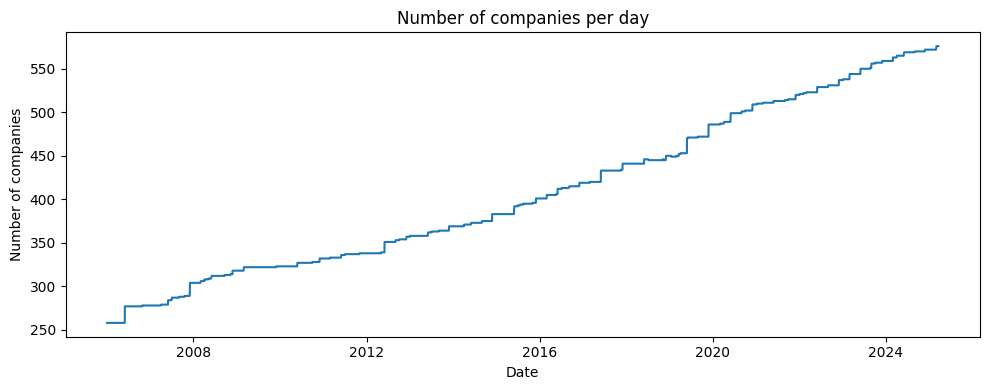

,Total_Return,Annualized_Return,Annualized_Volatility,Max_Drawdown
mom,616.2%,11.0%,19.9%,-45.1%
vol,569.0%,10.6%,18.5%,-42.5%
roe,710.6%,11.8%,20.0%,-44.8%
index,646.5%,11.3%,20.3%,-47.4%


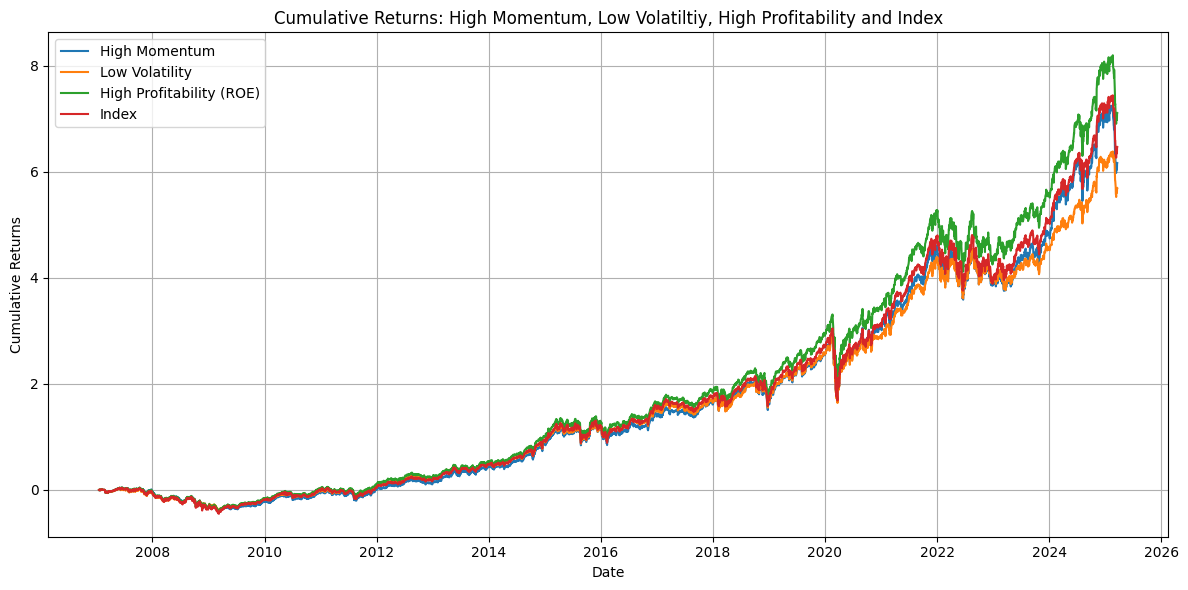

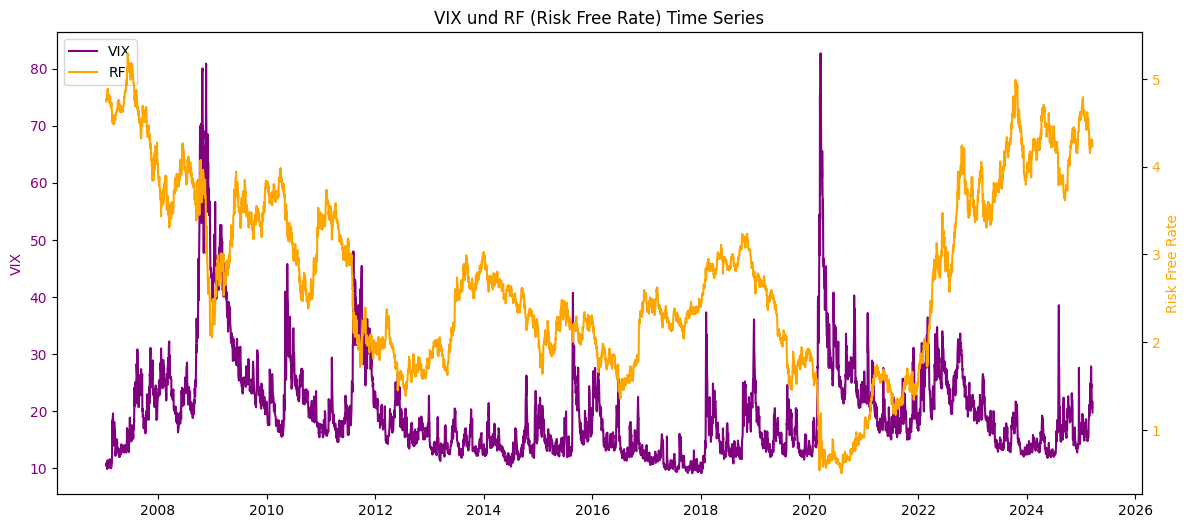

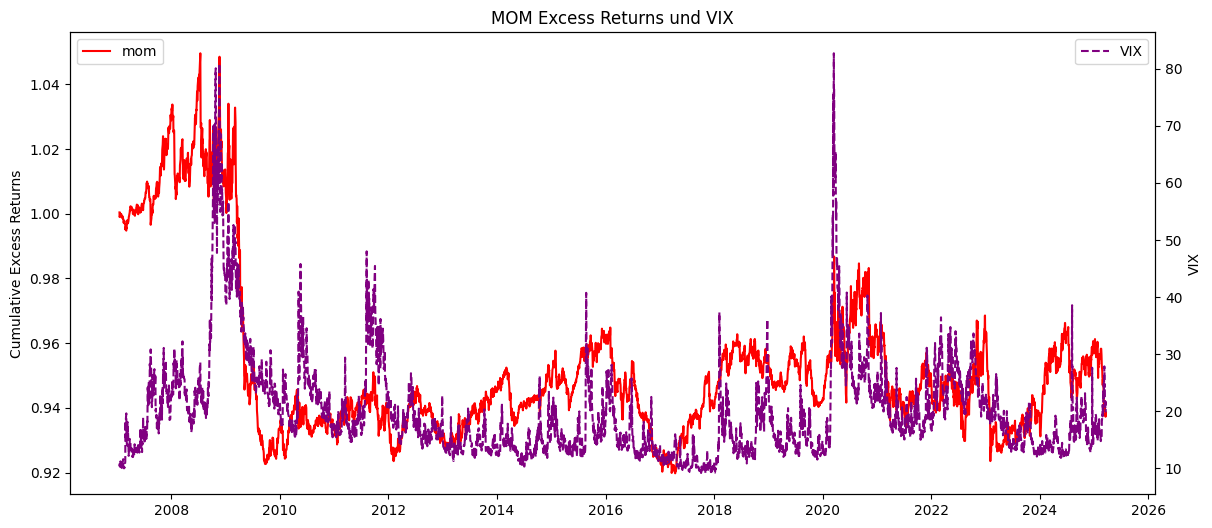

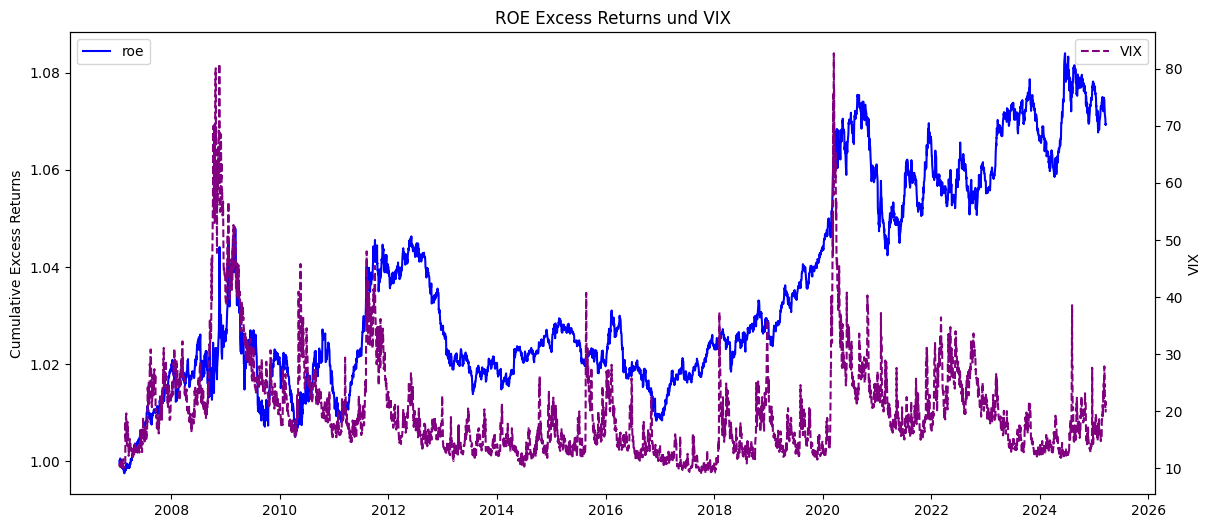

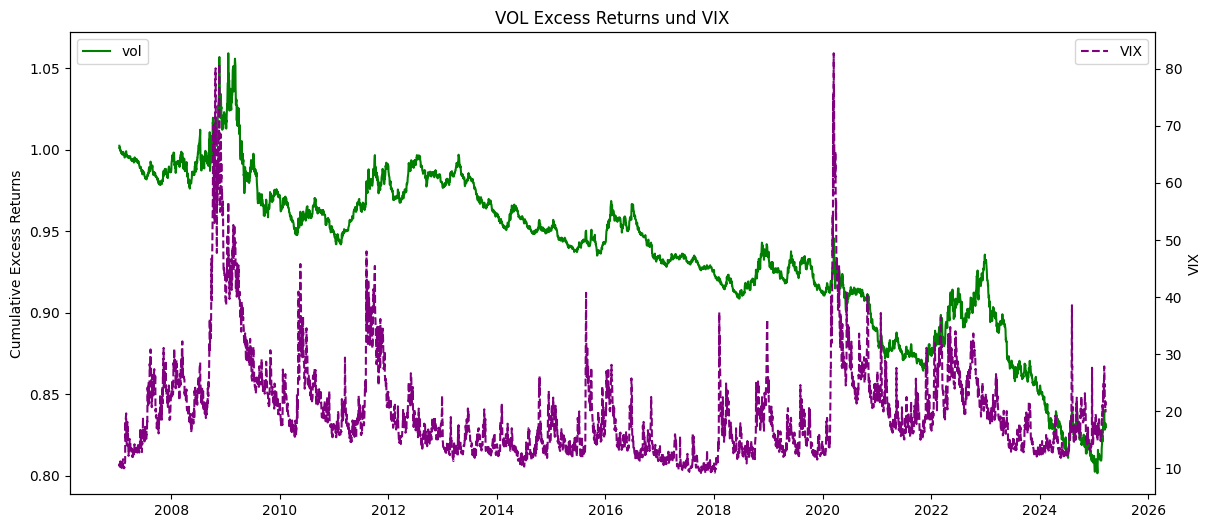

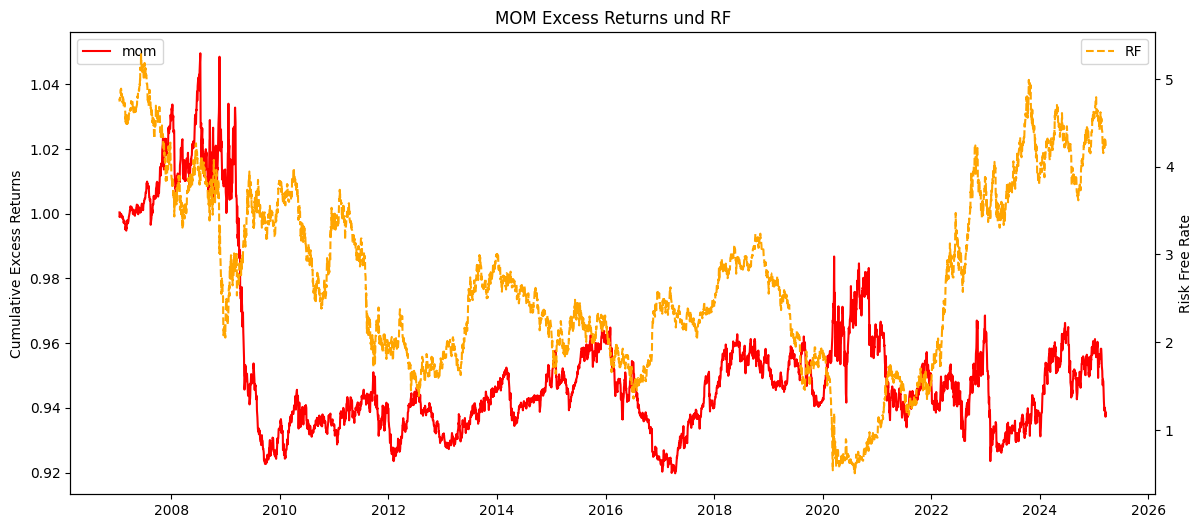

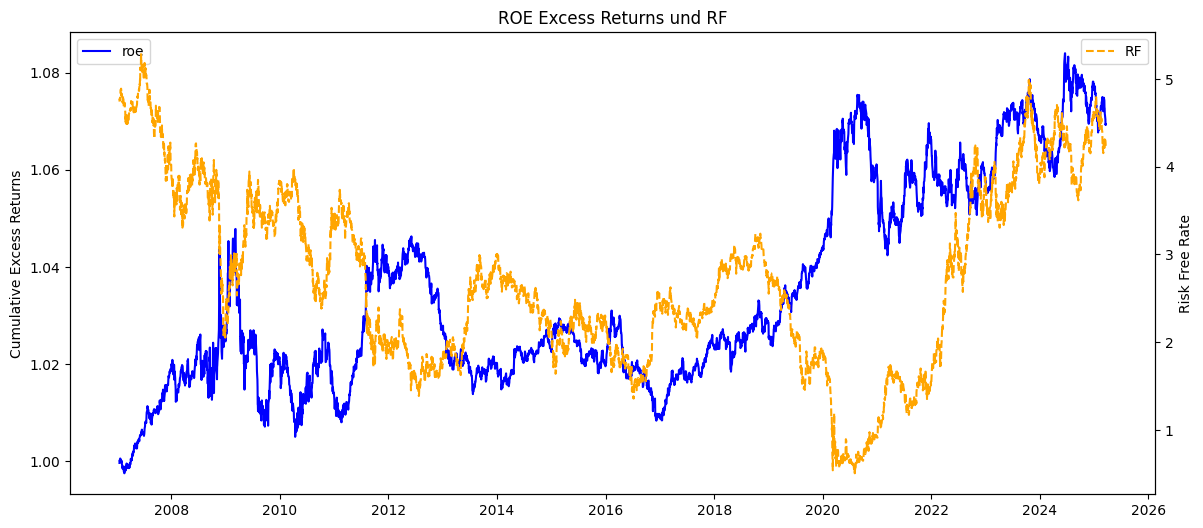

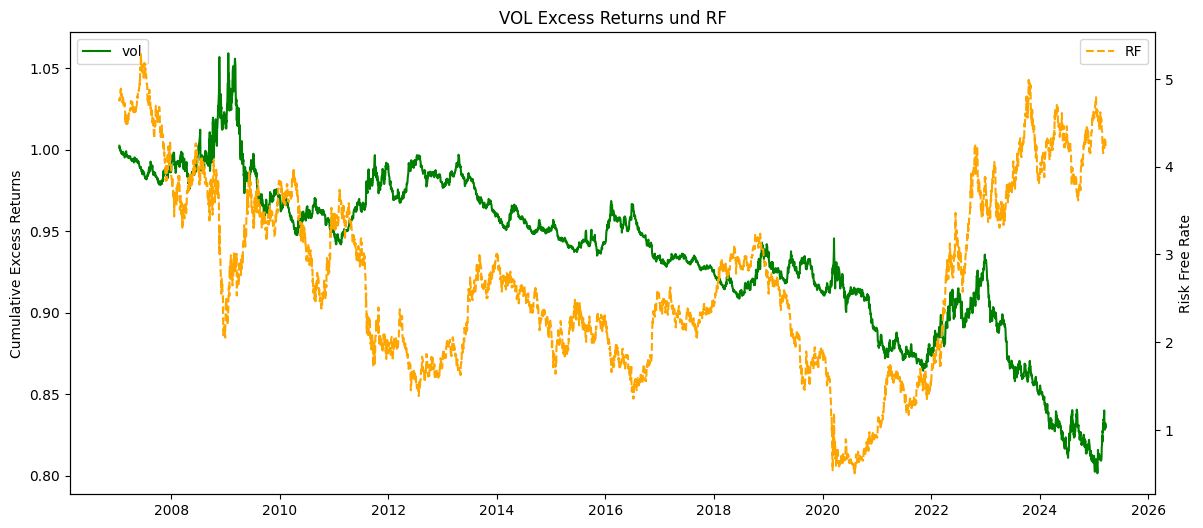

In [13]:
results = run_ml_backtests([dict(name="Descriptives")], params_)

df_dict = [res['GetStockScores'].return_stats for res in results]
display(df_dict[0]['basic_info'])
display(df_dict[0]['availability_stats'].style.format('{:.1f}'))

for res in results:
    display(res['GetStockScores'].numb_companies_fig)

df = pd.concat([res['GetStockScores'].factor_stats for res in results])
display(df.style.format('{:.1%}'))

for res in results:
    display(res['GetStockScores'].cum_returns_fig)

for res in results:
    display(res['GetStockScores'].rf_vix_fig)

for res in results:
    figs_dict = res['GetStockScores'].vix_excess_return_figs
    for fig in figs_dict.values():
        display(fig)

for res in results:
    figs_dict = res['GetStockScores'].rf_excess_returns_figs
    for fig in figs_dict.values():
        display(fig)

## 8.2 ⏳ Choice of Training Period

The **training period** defines the historical window used to estimate the machine learning model.
A careful split between **in-sample (training)** and **out-of-sample (testing)** is essential
to ensure valid performance evaluation.

### 🔹 Training Window
- Covers a **fixed historical range** (e.g., 2007–2012).
- Provides sufficient observations across different **market regimes**.
- Allows the model to learn factor relationships and their dependence on macro conditions.

### 🔹 Testing Window
- Starts immediately **after the training period**.
- Ensures that evaluation is conducted on **unseen data**.
- Mimics a realistic investment scenario where the model is applied **forward in time**.

### 🔹 Rationale
- Avoids **look-ahead bias** by separating training and testing.
- Guarantees that results reflect **predictive power**, not overfitting.
- Testing across different sub-periods allows to check for **robustness**.

---

**Purpose**
The choice of training and testing periods ensures that the ML strategy is evaluated
under realistic conditions and across diverse market environments.
This design is critical for assessing the **true generalization ability** of the model.


In [14]:
# 1. Set model specifications
model_definitions = [
    dict(name="Model 1",
         training_end_period='2009-12-31',
         test_start_period='2010-01-01',
         ml_training_factors=['mom_roe_corr', 'past_mom_return', 'past_roe_return', 'past_index_return', 'past_index_vola', 'rf', 'vix']),
    dict(name="Model 2",
         training_end_period='2010-12-31',
         test_start_period='2011-01-01',
         ml_training_factors=['mom_roe_corr', 'past_mom_return', 'past_roe_return', 'past_index_return', 'past_index_vola', 'rf', 'vix']),
    dict(name="Model 3",
         training_end_period='2015-12-31',
         test_start_period='2016-01-01',
         ml_training_factors=['mom_roe_corr', 'past_mom_return', 'past_roe_return', 'past_index_return', 'past_index_vola', 'rf', 'vix']),
    dict(name="Model 4",
         training_end_period='2020-12-31',
         test_start_period='2021-01-01',
         ml_training_factors=['mom_roe_corr', 'past_mom_return', 'past_roe_return', 'past_index_return', 'past_index_vola', 'rf', 'vix'])
]

# 2. Run models
results = run_ml_backtests(model_definitions, params_)

# 3. Display results
print("Average Factor Weights over Time)")
df = pd.concat([res['AverageFactorWeights'] for res in results])
display(df.style.format('{:.1%}'))
print("Goodness of model (in-sample-test)")
df = pd.concat([res['GoodnessOfModel'] for res in results])
display(df.style.format('{:.1%}'))
print("Goodness of model (out-of-sample-test)")
df = pd.concat([res['ExcessReturns'] for res in results])
display(df.style.format('{:.2%}'))
print("Feature Importance")
df = pd.concat([res['FeatureImportance'] for res in results])
display(df.style.format('{:.2f}'))
print("Feature Stats")
df = pd.concat([res['FeatureStats'] for res in results])
display(df.style.format('{:.2f}'))

Average Factor Weights over Time)


,mom,roe
Model 1,33.4%,66.6%
Model 2,58.3%,41.7%
Model 3,60.1%,39.9%
Model 4,53.1%,46.9%


Goodness of model (in-sample-test)


,R² on training
Model 1,83.4%
Model 2,81.6%
Model 3,82.0%
Model 4,83.5%


Goodness of model (out-of-sample-test)


,ML_minus_AVG_ML,ML_minus_5050,ML_minus_INDEX
Model 1,-0.03%,0.00%,0.34%
Model 2,-0.02%,-0.06%,0.29%
Model 3,-0.16%,-0.22%,0.01%
Model 4,-0.40%,-0.43%,-0.54%


Feature Importance


,past_mom_return,past_roe_return,rf,vix,past_index_return,past_index_vola
Model 1,0.19,0.10,0.43,0.09,0.10,0.10
Model 2,0.13,0.10,0.33,0.21,0.10,0.14
Model 3,0.12,0.10,0.21,0.26,0.11,0.20
Model 4,0.16,0.12,0.21,0.19,0.12,0.20


Feature Stats


,past_mom_return,past_roe_return,rf,vix,past_index_return,past_index_vola
Model 1,0.69,0.76,0.10,0.35,0.81,0.58
Model 2,0.74,0.75,0.07,0.34,0.79,0.62
Model 3,0.98,0.96,0.92,0.15,0.96,0.66
Model 4,0.98,0.93,0.54,0.43,0.86,0.82


## 8.3 🧩 Choice of Feature Variables

The **feature set** determines which signals the machine learning model can exploit.
Features are constructed from **factor portfolios**, **cross-sectional properties**, and **macro indicators**.

### 🔹 Factor-Based Features
- **Past factor returns**:
  - Momentum portfolio return
  - Volatility-sorted portfolio return
  - ROE portfolio return
- Capture how factors performed recently, guiding the model on their predictive strength.

### 🔹 Cross-Sectional Statistics
- **Standard deviations**: dispersion of MOM, VOL, ROE across stocks.
- **Correlations**:
  - MOM–VOL correlation
  - MOM–ROE correlation
- Provide structure of factor relationships and diversification potential.

### 🔹 Macro / Market Indicators
- **Risk-free rate (RF)** – reflects funding environment.
- **VIX** – proxy for market-wide volatility and risk aversion.

### 🔹 Market State Variables
- **Past index return** – benchmark performance over the lookback window.
- **Index volatility** – realized risk of the index over the same horizon.

---

**Purpose**
The selected features jointly capture **factor dynamics**, **cross-sectional structures**, and **macro conditions**.
They provide the ML model with a balanced view of both **stock-specific** and **market-wide drivers**,
allowing it to infer optimal factor blend weights under different environments.


In [15]:
# 1. Set model specifications
model_definitions = [
    dict(name="Model 5",
         training_end_period='2014-12-31',
         test_start_period='2015-01-01',
         ml_training_factors=['mom_roe_corr', 'past_mom_return', 'past_roe_return']),
    dict(name="Model 6",
         training_end_period='2014-12-31',
         test_start_period='2015-01-01',
         ml_training_factors=['past_mom_return', 'past_roe_return']),
    dict(name="Model 7",
         training_end_period='2014-12-31',
         test_start_period='2015-01-01',
         ml_training_factors=['rf', 'vix']),
    dict(name="Model 8",
         training_end_period='2014-12-31',
         test_start_period='2015-01-01',
         ml_training_factors=['past_index_return', 'past_index_vola']),
    dict(name="Model 9",
         training_end_period='2014-12-31',
         test_start_period='2015-01-01',
         ml_training_factors=['rf']),
    dict(name="Model 10",
         training_end_period='2014-12-31',
         test_start_period='2015-01-01',
         ml_training_factors=['vix'])
    ]

# 2. Run models
results = run_ml_backtests(model_definitions, params_)

# 3. Display results
print("Average Factor Weights over Time)")
df = pd.concat([res['AverageFactorWeights'] for res in results])
display(df.style.format('{:.1%}'))
print("Goodness of model (in-sample-test)")
df = pd.concat([res['GoodnessOfModel'] for res in results])
display(df.style.format('{:.1%}'))
print("Goodness of model (out-of-sample-test)")
df = pd.concat([res['ExcessReturns'] for res in results])
display(df.style.format('{:.2%}'))
print("Feature Importance")
df = pd.concat([res['FeatureImportance'] for res in results])
display(df.style.format('{:.2f}'))
print("Feature Stats")
df = pd.concat([res['FeatureStats'] for res in results])
display(df.style.format('{:.2f}'))

Average Factor Weights over Time)


,mom,roe
Model 5,56.3%,43.7%
Model 6,56.3%,43.7%
Model 7,62.2%,37.8%
Model 8,58.1%,41.9%
Model 9,57.6%,42.4%
Model 10,56.7%,43.3%


Goodness of model (in-sample-test)


,R² on training
Model 5,78.2%
Model 6,78.2%
Model 7,82.4%
Model 8,80.6%
Model 9,75.0%
Model 10,75.5%


Goodness of model (out-of-sample-test)


,ML_minus_AVG_ML,ML_minus_5050,ML_minus_INDEX
Model 5,-0.04%,-0.07%,0.18%
Model 6,-0.04%,-0.07%,0.18%
Model 7,0.22%,0.17%,0.42%
Model 8,-0.28%,-0.31%,-0.07%
Model 9,0.29%,0.26%,0.51%
Model 10,-0.11%,-0.14%,0.11%


Feature Importance


,past_mom_return,past_roe_return,rf,vix,past_index_return,past_index_vola
Model 5,0.53,0.47,nan,nan,nan,nan
Model 6,0.53,0.47,nan,nan,nan,nan
Model 7,nan,nan,0.50,0.50,nan,nan
Model 8,nan,nan,nan,nan,0.49,0.51
Model 9,nan,nan,1.00,nan,nan,nan
Model 10,nan,nan,nan,1.00,nan,nan


Feature Stats


,past_mom_return,past_roe_return,rf,vix,past_index_return,past_index_vola
Model 5,0.77,0.83,nan,nan,nan,nan
Model 6,0.77,0.83,nan,nan,nan,nan
Model 7,nan,nan,0.69,0.17,nan,nan
Model 8,nan,nan,nan,nan,0.84,0.50
Model 9,nan,nan,0.69,nan,nan,nan
Model 10,nan,nan,nan,0.17,nan,nan


## 8.4. 🤖 Choice of Machine Learning Model

The machine learning model is responsible for mapping **input features**
to the **optimal factor blend weights**. Several algorithms are considered,
each with specific strengths and trade-offs.

### 🔹 Random Forest Regressor
- Ensemble of decision trees using **bagging**.
- Handles **non-linearities** and **feature interactions** well.
- Robust to noise but may require many estimators.

### 🔹 LightGBM
- Gradient boosting framework optimized for **speed and efficiency**.
- Handles large feature spaces and complex interactions.
- Provides **feature importance** for interpretability.

### 🔹 XGBoost
- Popular gradient boosting library with strong performance.
- Supports regularization to avoid overfitting.
- Typically slower than LightGBM but often more stable.

### 🔹 CatBoost
- Gradient boosting with improved handling of **categorical features**.
- Built-in mechanisms reduce overfitting and variance.
- Slower training but often **more accurate** in complex setups.

---

**Rationale**
- Tree-based ensemble models are chosen due to their ability to **capture non-linear factor relationships**.
- They are robust against multicollinearity and do not require feature scaling.
- Multiple algorithms are tested to compare performance and **robustness across regimes**.

**Purpose**
The choice of ML model is critical to balance **predictive accuracy**, **interpretability**,
and **computational efficiency** in the backtest framework.


In [16]:
# 1. Set model specifications
model_definitions = [
    dict(name="Model 11",
         training_end_period='2014-12-31',
         test_start_period='2015-01-01',
         ml_training_factors=['rf'],
         ml_model='RandomForestRegressor'),
    dict(name="Model 12",
         training_end_period='2014-12-31',
         test_start_period='2015-01-01',
         ml_training_factors=['rf'],
         ml_model='lightgbm'),
    dict(name="Model 13",
         training_end_period='2014-12-31',
         test_start_period='2015-01-01',
         ml_training_factors=['rf'],
         ml_model='xgboost'),
    dict(name="Model 14",
         training_end_period='2014-12-31',
         test_start_period='2015-01-01',
         ml_training_factors=['rf'],
         ml_model='catboost')
]

# 2. Run models
results = run_ml_backtests(model_definitions, params_)

# 3. Display results
print("Average Factor Weights over Time)")
df = pd.concat([res['AverageFactorWeights'] for res in results])
display(df.style.format('{:.1%}'))
print("Goodness of model (in-sample-test)")
df = pd.concat([res['GoodnessOfModel'] for res in results])
display(df.style.format('{:.1%}'))
print("Goodness of model (out-of-sample-test)")
df = pd.concat([res['ExcessReturns'] for res in results])
display(df.style.format('{:.2%}'))
print("Feature Importance")
df = pd.concat([res['FeatureImportance'] for res in results])
display(df.style.format('{:.2f}'))
print("Feature Stats")
df = pd.concat([res['FeatureStats'] for res in results])
display(df.style.format('{:.2f}'))

Average Factor Weights over Time)


,mom,roe
Model 11,57.6%,42.4%
Model 12,58.4%,41.6%
Model 13,50.2%,49.8%
Model 14,55.2%,44.8%


Goodness of model (in-sample-test)


,R² on training
Model 11,75.0%
Model 12,9.0%
Model 13,100.0%
Model 14,63.0%


Goodness of model (out-of-sample-test)


,ML_minus_AVG_ML,ML_minus_5050,ML_minus_INDEX
Model 11,0.29%,0.26%,0.51%
Model 12,-0.03%,-0.06%,0.18%
Model 13,0.21%,0.21%,0.45%
Model 14,0.14%,0.12%,0.37%


Feature Importance


,rf
Model 11,1.00
Model 12,249.00
Model 13,1.00
Model 14,100.00


Feature Stats


,rf
Model 11,0.69
Model 12,0.69
Model 13,0.69
Model 14,0.69


## 8.5. 📉 Choice of Relevant Factors

The strategy focuses on **equity style factors** that are well-established in the
academic and practitioner literature. For each model run, a subset of factors is
selected as **inputs to the ML-based weighting scheme**.

### 🔹 Core Factors
- **Momentum (MOM)**
  Stocks with strong past performance tend to continue outperforming in the short term.
- **Volatility (VOL)**
  Low-volatility stocks historically offer higher risk-adjusted returns.
- **Profitability (ROE)**
  Companies with high return on equity are associated with persistent excess returns.

### 🔹 Factor Selection Process
- Factors are **not all used simultaneously**.
- Instead, the ML model blends **two factors** at a time, with weights dynamically predicted.
- Example combinations:
  - Momentum + ROE
  - Momentum + Volatility

### 🔹 Rationale
- Reduces the **dimensionality** of the problem, making the learning task tractable.
- Reflects the investment reality where **trade-offs** between two factors drive allocation.
- Enables clear attribution of performance im


In [17]:
# 1. Set model specifications
model_definitions = [
    dict(name="Model 15",
         training_end_period='2014-12-31',
         test_start_period='2015-01-01',
         ml_training_factors=['rf'],
         relevant_factors = ['mom', 'roe'],
         ml_model='xgboost'),
    dict(name="Model 16",
         training_end_period='2014-12-31',
         test_start_period='2015-01-01',
         ml_training_factors=['rf'],
         relevant_factors = ['mom', 'vol'],
         ml_model='xgboost'),
    dict(name="Model 17",
         training_end_period='2014-12-31',
         test_start_period='2015-01-01',
         ml_training_factors=['rf'],
         relevant_factors = ['roe', 'vol'],
         ml_model='xgboost')
]

# 2. Run models
results = run_ml_backtests(model_definitions, params_)

# 3. Display results
print("Average Factor Weights over Time)")
df = pd.concat([res['AverageFactorWeights'] for res in results])
display(df.style.format('{:.1%}'))
print("Goodness of model (in-sample-test)")
df = pd.concat([res['GoodnessOfModel'] for res in results])
display(df.style.format('{:.1%}'))
print("Goodness of model (out-of-sample-test)")
df = pd.concat([res['ExcessReturns'] for res in results])
display(df.style.format('{:.2%}'))
print("Feature Importance")
df = pd.concat([res['FeatureImportance'] for res in results])
display(df.style.format('{:.2f}'))
print("Feature Stats")
df = pd.concat([res['FeatureStats'] for res in results])
display(df.style.format('{:.2f}'))

Average Factor Weights over Time)


,mom,roe,vol
Model 15,50.2%,49.8%,nan%
Model 16,63.1%,nan%,36.9%
Model 17,nan%,50.0%,50.0%


Goodness of model (in-sample-test)


,R² on training
Model 15,100.0%
Model 16,100.0%
Model 17,100.0%


Goodness of model (out-of-sample-test)


,ML_minus_AVG_ML,ML_minus_5050,ML_minus_INDEX
Model 15,0.21%,0.21%,0.45%
Model 16,-0.33%,-0.10%,-0.99%
Model 17,0.66%,0.66%,0.03%


Feature Importance


,rf
Model 15,1.00
Model 16,1.00
Model 17,1.00


Feature Stats


,rf
Model 15,0.69
Model 16,0.93
Model 17,0.35


## 8.6. 🏆 Summary: Best Out-of-Sample Model

After testing different **training windows**, **feature sets**, and **ML algorithms**,
the results highlight the **best-performing configuration** in terms of
out-of-sample performance.

### 🔹 Key Findings
- The best model achieved **superior risk-adjusted returns** compared to benchmarks
  (50/50 blend, average ML weights, index).
- **Tree-based boosting methods** (e.g., LightGBM or CatBoost) generally outperformed
  Random Forest in terms of predictive stability.
- The inclusion of **macro variables (RF, VIX)** improved regime detection and
  helped the model adjust factor weights dynamically.
- Optimal results were obtained when blending **Momentum and ROE**, confirming
  that combining trend-following with profitability is robust across regimes.

### 🔹 Performance Comparison
- **ML Model**: highest annualized return with controlled volatility.
- **50/50 Blend**: reasonable baseline but inferior in drawdown protection.
- **Average ML Weights**: closer to equal weighting, weaker in adapting to shifts.
- **Index**: underperformed factor-based allocations in most tests.

---

**Conclusion**
The out-of-sample evidence suggests that **ML-driven factor weighting**
adds tangible value over static allocation.
By incorporating **macro indicators** and **cross-factor signals**,
the chosen model adapts flexibly to changing market conditions,
leading to improved **portfolio efficiency**.


In [18]:
# 1. Set model specifications
model_definitions = [
    dict(name="Model 18",
         training_end_period='2014-12-31',
         test_start_period='2015-01-01',
         ml_training_factors=['rf'],
         relevant_factors = ['roe', 'vol'],
         ml_model='xgboost')
]

# 2. Run models
results = run_ml_backtests(model_definitions, params_)

# 3. Display results
print("Average Factor Weights over Time)")
df = pd.concat([res['AverageFactorWeights'] for res in results])
display(df.style.format('{:.1%}'))
print("Goodness of model (in-sample-test)")
df = pd.concat([res['GoodnessOfModel'] for res in results])
display(df.style.format('{:.1%}'))
print("Goodness of model (out-of-sample-test)")
df = pd.concat([res['ExcessReturns'] for res in results])
display(df.style.format('{:.2%}'))
print("Feature Importance")
df = pd.concat([res['FeatureImportance'] for res in results])
display(df.style.format('{:.2f}'))
print("Feature Stats")
df = pd.concat([res['FeatureStats'] for res in results])
display(df.style.format('{:.2f}'))

Average Factor Weights over Time)


,roe,vol
Model 18,50.0%,50.0%


Goodness of model (in-sample-test)


,R² on training
Model 18,100.0%


Goodness of model (out-of-sample-test)


,ML_minus_AVG_ML,ML_minus_5050,ML_minus_INDEX
Model 18,0.66%,0.66%,0.03%


Feature Importance


,rf
Model 18,1.00


Feature Stats


,rf
Model 18,0.35


# 9. 🔮 Conclusion & Next Steps

### ✅ Conclusion
This project demonstrates that **machine learning can successfully enhance a multi-factor equity strategy**
by dynamically adjusting factor blend weights based on historical signals and macro variables.
Compared to static benchmarks (50/50 blend, average ML weights, index), the ML-based approach shows:

- Higher **annualized returns**
- Improved **risk-adjusted performance** (Sharpe ratio)
- Better **drawdown management** in adverse regimes

The methodology highlights the benefits of combining **Momentum** and **Profitability (ROE)** factors,
with models such as **LightGBM** providing strong predictive power and robustness.
The results confirm that **dynamic weighting**, rather than static allocation,
is a key driver of improved portfolio outcomes.

---

### 🚀 Next Steps
To further extend and strengthen the framework:

1. **Expand Feature Set**
   - Include macroeconomic indicators (e.g., inflation, interest rate spreads, credit spreads).
   - Test market sentiment measures beyond VIX.

2. **Broaden Factor Universe**
   - Add additional equity style factors (e.g., Value, Quality, Size).
   - Explore sector-specific factor timing.

3. **Robustness Checks**
   - Perform **rolling window backtests** to test stability across different regimes.
   - Apply **cross-validation** techniques for more reliable model selection.

4. **Portfolio Enhancements**
   - Incorporate **transaction costs and turnover constraints**.
   - Extend from **long-only** to **long-short** factor strategies.

5. **Production Deployment**
   - Automate data pipelines and reporting.
   - Build monitoring tools for **live strategy evaluation**.

---

**Final Remark**
This project provides a **proof of concept** for applying machine learning in systematic equity investing.
While promising, further work is required to ensure **out-of-sample robustness** and
**real-world implementability** before deployment in production portfolios.
